# FlipSide

### An open-source radiation-hardening library and cost–reliability explorer for SKY130

Mac Rogers · The University of Queensland, Australia

IEEE SSCS Code-a-Chip Travel Grant, ISSCC 2027 · Apache License 2.0

---

Radiation hardening is usually summarised in one line: triplicate the register and vote. What that costs in silicon,
and how much protection it actually buys, is rarely measured, and almost never in a flow anyone can reproduce.

This notebook builds `prot_reg`, a library of protected registers with five hardening modes behind one interface,
and uses it to harden a real safety-critical design: the parachute-deployment controller of a high-power rocket.
Each mode is measured on two axes. Cost is the area, flip-flop count and maximum clock frequency after full
RTL-to-GDS implementation in SKY130 with LibreLane. Reliability comes from thousands of simulated flights with
single-event upsets injected into every storage bit, scored by whether the parachutes deploy correctly.

The study turned up five results that are easy to get wrong in practice:

1. Textbook TMR with `(* keep *)` on its registers is silently merged back into a single copy by synthesis. It
   simulates as protected and fabricates as unprotected.
2. Feedback TMR, which repairs itself every clock, is smaller than plain TMR, and plain TMR fails under fault
   accumulation.
3. Hamming coding only saves area on registers of 8 bits or more, and in a state machine it halves the maximum clock
   frequency.
4. The fault campaign caught a real bug: the detect-only (DMR) controller fired a parachute under thrust for one clock
   cycle. The fix is a one-line design rule, shown before and after.
5. The placer stacks the three copies of each bit on top of each other. In the routed layout a strike that upsets
   two neighbouring cells defeats TMR_FB in about one flight in six; keeping each copy in its own region of the
   core removes the problem without changing the logic.

All RTL is written by the cells below, and every number in the text is produced by code in this notebook.

#### Contents

1. Setup
2. Motivation
3. The `prot_reg` library
4. Verifying every mode
5. The demonstrator: a dual-deploy recovery controller
6. The synthesis trap
7. RTL to GDS, step by step
8. Implementation cost
9. Maximum clock frequency
10. Reliability: the fault-injection campaign
11. A bug found by the campaign
12. The cost–reliability trade-off
13. Scaling with register width
14. Power
15. Design rules
16. Limitations and future work
17. Reproducing this notebook
18. References

## 1. Setup

On Google Colab, the next two cells install Nix, LibreLane with its EDA tools, the SKY130 PDK and Icarus Verilog,
which takes about ten minutes. They are adapted from LibreLane's official Colab notebook. To run locally, start
Jupyter from inside LibreLane's `nix-shell`; the install cells detect that they are not on Colab and do nothing.

In [18]:
# @title Install Nix (Colab only)
import os, sys, shutil, subprocess, tempfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if IN_COLAB:
    if shutil.which("nix-env") is None:
        with tempfile.TemporaryDirectory() as d:
            installer_path = Path(d) / "nix"
            !curl --proto '=https' --tlsv1.2 -sSf -L https://install.determinate.systems/nix > {installer_path}
            with subprocess.Popen(
                ["bash", installer_path, "install", "--prefer-upstream-nix", "--no-confirm",
                 "--extra-conf",
                 "extra-substituters = https://nix-cache.fossi-foundation.org\n"
                 "extra-trusted-public-keys = nix-cache.fossi-foundation.org:3+K59iFwXqKsL7BNu6Guy0v+uTlwsxYQxjspXzqLYQs=\n"],
                stdout=subprocess.PIPE, stderr=subprocess.STDOUT, encoding="utf8",
            ) as p:
                for line in p.stdout:
                    print(line, end="")
    os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin/:{os.getenv('PATH')}"
else:
    print("Not on Colab: assuming this kernel was started inside LibreLane's nix-shell.")

Not on Colab: assuming this kernel was started inside LibreLane's nix-shell.


In [53]:
# @title Install LibreLane, the SKY130 PDK and Icarus Verilog (Colab only)
LIBRELANE_VERSION = "3.0.14"   # pin to a release tag for reproducibility (section 17)
PDK_ROOT = os.path.expanduser("~/.ciel")
PDK = "sky130"

if IN_COLAB:
    import yaml, IPython
    librelane_ipynb_path = os.path.join(os.getcwd(), "librelane_ipynb")
    display(IPython.display.HTML("<h4>Downloading LibreLane…</h4>"))
    !rm -rf {librelane_ipynb_path}
    !mkdir -p {librelane_ipynb_path}
    !curl -L "https://github.com/librelane/librelane/tarball/{LIBRELANE_VERSION}" | tar -xzC {librelane_ipynb_path} --strip-components 1
    try:
        import tkinter
    except ImportError:
        !sudo apt-get install -y python3-tk
    display(IPython.display.HTML("<h4>Installing EDA tools with Nix…</h4>"))
    with subprocess.Popen(["nix", "profile", "install", ".#colab-env"], cwd=librelane_ipynb_path,
                          stdout=subprocess.PIPE, stderr=subprocess.STDOUT, encoding="utf8") as p:
        for line in p.stdout:
            print(line, end="")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "."], cwd=librelane_ipynb_path)
    display(IPython.display.HTML("<h4>Downloading the SKY130 PDK…</h4>"))
    import ciel
    from ciel.source import StaticWebDataSource
    with open(os.path.join(librelane_ipynb_path, "librelane", "pdk_hashes.yaml")) as f:
        pdk_hashes = yaml.safe_load(f)
    ciel.enable(ciel.get_ciel_home(PDK_ROOT), PDK, pdk_hashes[PDK],
                data_source=StaticWebDataSource("https://fossi-foundation.github.io/ciel-releases"))
    sys.path.insert(0, librelane_ipynb_path)
    !sudo apt-get install -y -qq iverilog > /dev/null
    import logging
    logging.getLogger().handlers.clear()
    display(IPython.display.HTML("<h4>Done.</h4>"))

In [20]:
# @title Check the environment
import importlib, json, math, re, time
from concurrent.futures import ThreadPoolExecutor

for pkg in ("pandas", "matplotlib", "jinja2"):
    try:
        importlib.import_module(pkg)
    except ImportError:
        %pip install -q {pkg}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

YOSYS = os.environ.get("YOSYS", "yosys")
LIBRELANE_CMD = ([shutil.which("librelane")] if shutil.which("librelane")
                 else [sys.executable, "-m", "librelane"])

try:
    import librelane
    LIBRELANE_VERSION_FOUND = librelane.__version__
except Exception:
    LIBRELANE_VERSION_FOUND = None


def find_tt_lib():
    """SKY130 HD standard-cell library, typical corner (used by the width sweep)."""
    if os.environ.get("SKY130_TT_LIB"):
        return os.environ["SKY130_TT_LIB"]
    root = Path(os.environ.get("PDK_ROOT", Path.home() / ".ciel"))
    name = "sky130_fd_sc_hd__tt_025C_1v80.lib"
    direct = root / "sky130A/libs.ref/sky130_fd_sc_hd/lib" / name
    if direct.is_file():
        return str(direct)
    hits = sorted(root.rglob(name)) if root.is_dir() else []
    return str(hits[0]) if hits else None


TT_LIB = find_tt_lib()
HAVE = {
    "LibreLane": LIBRELANE_VERSION_FOUND is not None and shutil.which("openroad") is not None,
    "Yosys": shutil.which(YOSYS) is not None,
    "Icarus Verilog": shutil.which("iverilog") is not None and shutil.which("vvp") is not None,
    "SKY130 library": TT_LIB is not None,
}
for k, v in HAVE.items():
    print(f"{k:<16}{'found' if v else 'not found'}")
print(f"{'LibreLane ver.':<16}{LIBRELANE_VERSION_FOUND}")

LibreLane       found
Yosys           found
Icarus Verilog  found
SKY130 library  found
LibreLane ver.  3.0.14


The full place-and-route sweep (five modes at four clock targets, twenty LibreLane runs) takes 20 to 40 minutes, so
by default the notebook uses the embedded results of a local run (section 8). Everything else runs live: the unit
tests, synthesis checks, the step-by-step layout (about 3 minutes) and the fault campaign (about 2 minutes).

In [21]:
RUN_STEP_BY_STEP = HAVE["LibreLane"]   # one design RTL -> GDS with layout snapshots (~3 min)
RUN_PNR          = False               # every mode x every clock target through LibreLane (20-40 min)
PNR_PERIODS_NS   = [20, 8, 5, 3.5]     # 20 ns: relaxed reference for area; tighter targets for fmax
PNR_WORKERS      = max(1, min(4, (os.cpu_count() or 2) // 2))

TRIALS_SINGLE = 3000                   # single-upset flights per mode
TRIALS_MC     = 1000                   # flights per mode per upset rate
SEED          = 1

MODES = ["none", "tmr", "tmr_fb", "hamming", "dmr"]
MODE_PARAM = {"none": "NONE", "tmr": "TMR", "tmr_fb": "TMR_FB", "hamming": "HAMMING", "dmr": "DMR"}

Shared presentation helpers. Each mode keeps the same colour and marker shape in every figure, so no figure relies on
colour alone, and each figure is also saved to `figures/` at print resolution.

In [22]:
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
MODE_COLOR  = {"none": MUTED, "tmr": "#2a78d6", "tmr_fb": "#eb6834", "hamming": "#1baf7a",
               "dmr": "#eda100", "dmr_ungated": "#e87ba4"}
MODE_MARKER = {"none": "o", "tmr": "s", "tmr_fb": "D", "hamming": "^", "dmr": "v", "dmr_ungated": "X"}
MODE_LABEL  = {"none": "NONE", "tmr": "TMR", "tmr_fb": "TMR_FB", "hamming": "HAMMING", "dmr": "DMR",
               "dmr_ungated": "DMR, ungated"}
OUTCOME_COLOR = {"NOMINAL": "#0ca30c", "SAFE": "#fab219", "LOSS_MISSED": "#ec835a", "LOSS_EARLY": "#d03b3b"}
OUTCOME_LABEL = {"NOMINAL": "Nominal: both parachutes on time",
                 "SAFE": "Fail-silent: fault detected, backup altimeter takes over",
                 "LOSS_MISSED": "Loss: parachute missed, late or short pulse",
                 "LOSS_EARLY": "Loss: parachute fired early, at speed"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "font.size": 10, "lines.linewidth": 2, "lines.markersize": 8,
    "legend.frameon": False, "figure.dpi": 110,
})
Path("figures").mkdir(exist_ok=True)
Path("build").mkdir(exist_ok=True)


def save(fig, name):
    fig.savefig(f"figures/{name}.png", dpi=200, bbox_inches="tight")


TABLE_CSS = [
    {"selector": "", "props": "border-collapse: collapse; font-size: 13px; margin: 4px 0 14px 0;"},
    {"selector": "caption", "props": "caption-side: top; text-align: left; font-weight: 600; padding: 0 0 8px 0;"},
    {"selector": "th", "props": "font-weight: 600; padding: 5px 14px; "
                                "border-bottom: 1px solid rgba(128,128,128,0.55); white-space: nowrap;"},
    {"selector": "th.row_heading", "props": "text-align: left; font-weight: 500;"},
    {"selector": "th.col_heading", "props": "text-align: right;"},
    {"selector": "td", "props": "padding: 5px 14px; text-align: right; font-variant-numeric: tabular-nums; "
                                "border-bottom: 1px solid rgba(128,128,128,0.18); white-space: nowrap;"},
]


def styled(df, fmt=None, caption=None):
    """A DataFrame as a clean, theme-neutral table (borders only, so it reads in light and dark themes)."""
    df = df.copy()
    df.index.name = None
    df.columns.name = None
    sty = df.style.set_table_styles(TABLE_CSS)
    if fmt is not None:
        sty = sty.format(fmt, na_rep="–")
    if caption:
        sty = sty.set_caption(caption)
    return sty


def table(df, fmt=None, caption=None):
    display(styled(df, fmt, caption))


def labelled(df):
    """Replace mode tags in the index with display names."""
    df = df.copy()
    df.index = [MODE_LABEL.get(i, i) for i in df.index]
    return df


def run(cmd, **kw):
    """Run a command; on failure show its output instead of a bare traceback."""
    r = subprocess.run(cmd, capture_output=True, text=True, **kw)
    if r.returncode != 0:
        print(r.stdout[-3000:], r.stderr[-3000:])
        raise RuntimeError(f"command failed: {' '.join(map(str, cmd))[:200]}")
    return r

## 2. Motivation

I have been flying high-altitude electronics for four years as the lead avionics engineer for UQSpace, the University
of Queensland's student rocketry team. Our flight computer is responsible for deploying the parachutes; as the key
differentiator between a scientific payload and a missile, it cannot fail. The controller in this notebook is
modelled on that same dual-deploy flight profile. Student and small-satellite teams increasingly build on open PDKs
and commercial parts with no radiation qualification. As I explore tape-outs for future projects, this notebook
answers a practical question: what does radiation-hardening the logic cost, and what does it buy?

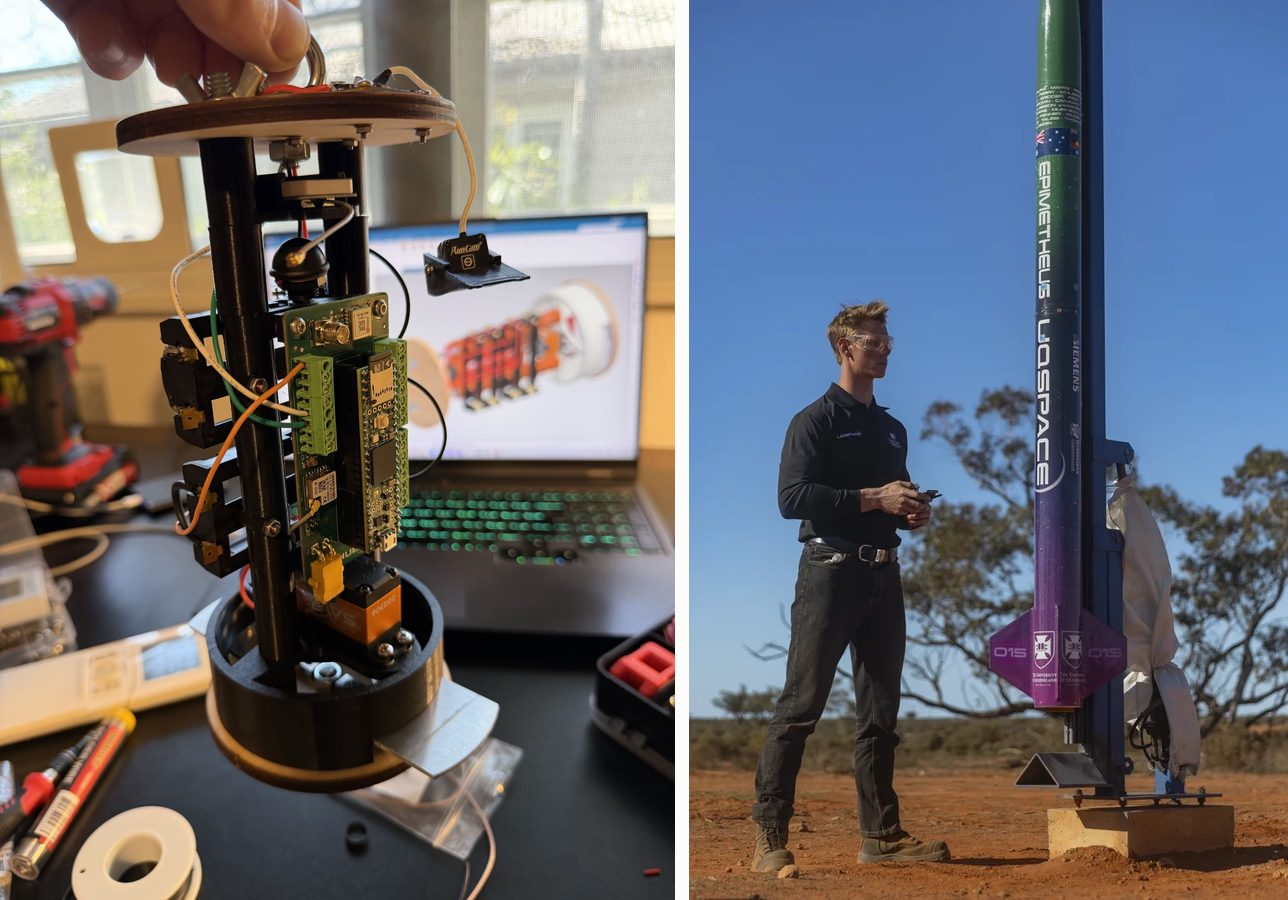

*Figure 1. Left: a UQSpace avionics bay on the bench. Right: the team's rocket, Epimetheus, on the launch rail.*

### Single-event upsets

When an energetic particle passes through a transistor it deposits charge. If the charge collected at a storage node
exceeds the node's critical charge, the flip-flop changes state. This is a single-event upset (SEU): nothing is
damaged, but one bit is now wrong. The same strike in combinational logic produces a short glitch, a single-event
transient (SET), and a strike that spreads across neighbouring cells can flip several bits at once, a multiple-bit
upset (MBU).

Not every upset matters. A bit that is overwritten before it is read is harmless, so the fraction of upsets that
actually cause a failure, the architectural vulnerability factor, has to be measured by simulating the real design
rather than assumed. The standard defences each trade silicon for protection:

| Strategy | Principle | Typical cost |
|:--|:--|:--|
| Triple modular redundancy (TMR) | three copies and a majority vote | about 3× storage, plus voters |
| TMR with feedback (scrubbing) | the voted value is written back every clock | as TMR, plus one shared mux |
| Error-correcting code (Hamming) | parity bits locate and correct one flipped bit | parity grows as log₂ of the width |
| Dual modular redundancy (DMR) | two copies, mismatch detected, fail safe | about 2× storage, no correction |

In a recovery controller, one flipped bit can fire a parachute during boost or skip it at apogee. Either outcome loses
the vehicle.

## 3. The `prot_reg` library

Every mode is a drop-in register with the same ports. On reset `q` takes `RST_VAL`; when `en` is high, `q` takes `d`
on the next clock; otherwise it holds. The `err` output reports a detected fault. Changing the `MODE` parameter
re-hardens any design built from `prot_reg` without touching the surrounding logic.

| `MODE` | Storage | Effect of one flipped bit | Storage repaired | `err` indicates |
|:--|:--|:--|:--|:--|
| `NONE` | W | wrong output | no | never asserted |
| `TMR` | 3W | outvoted | only when next written | copies disagree |
| `TMR_FB` | 3W | outvoted | every clock | copies disagreed; heals next clock |
| `HAMMING` | W + ⌈log₂⌉ parity | corrected | every clock (scrubbing) | non-zero syndrome |
| `DMR` | 2W | detected, not corrected | no | copies disagree; persists |

A sixth mode, `TMR_NOKEEP`, is a deliberately broken control case used in section 6.

Two implementation details matter as much as the logic itself. First, Yosys's `opt_merge` pass folds flip-flops with
identical inputs into one, and three copies of a register have identical inputs by construction. A `(* keep *)`
attribute on the register declaration only protects the wire; placed on the `always` block, it is copied onto the
flip-flop cell, which `opt_merge` never merges. The netlist stays flat, as LibreLane requires. Second, the Hamming
encoder and decoder are written as constant XOR wiring, with parity masks computed by constant functions at
elaboration. The hardware is a set of plain XOR trees, and it simulates about 17 times faster than a loop-based
description.

In [23]:
%%writefile prot_reg.v
// prot_reg.v -- protected register library
//
// From the outside every mode behaves like an ordinary register:
//   rst -> q = RST_VAL ;  en -> q = d on the next clock ;  else q holds
// and raises err when it detects a fault.
//
// MODE         copies  corrects?  repairs storage?   err means
// ----------   ------  ---------  ----------------   -------------------------
// NONE           1       no          -               (tied low)
// TMR            3       yes         only on write   copies disagree
// TMR_FB         3       yes         every clock     copies disagreed (heals next clock)
// HAMMING        1*      yes (1 bit) every clock     nonzero syndrome (heals next clock)
// DMR            2       no          no              copies disagree (persists)
// TMR_NOKEEP   control: TMR without keep -> synthesis merges it back to ONE copy
//
//   * HAMMING stores one SEC codeword of W + R bits, R = parity bits
//     (W=1 -> 3 bits, W=3 -> 6, W=8 -> 12, W=16 -> 21).
//     Single-error-correcting only: two flips in one word miscorrect silently.
//   DMR cannot tell which copy is right: q follows copy 0, and the
//   surrounding design must react to err (e.g. go to a safe state).
//
// Storage registers are named r0, r1, r2 in every mode (HAMMING: r0 is the
// codeword), inside a generate block named g, so a fault-injection harness
// can reach them at <instance>.g.r0[bit] regardless of mode.
//
// How the redundancy survives synthesis:
//   Yosys's opt_merge folds flip-flops with identical inputs into one.
//   (* keep *) on a `reg` only protects the WIRE; (* keep *) on the `always`
//   block lands on the flip-flop CELL, and opt_merge never merges a kept cell.
//   The netlist stays flat, as LibreLane requires.
// (* fsm_encoding = "none" *) stops Yosys re-encoding a state register
// (e.g. to one-hot) in some modes only, which would make modes incomparable.

`default_nettype none

module prot_reg #(
    parameter integer W       = 8,
    parameter         MODE    = "NONE",
    parameter [W-1:0] RST_VAL = {W{1'b0}}
)(
    input  wire         clk,
    input  wire         rst,
    input  wire         en,
    input  wire [W-1:0] d,
    output wire [W-1:0] q,
    output wire         err
);

    // ---------------- Hamming SEC helpers (used by MODE="HAMMING") ----------------
    // Codeword positions 1..N; parity bits sit at positions 1,2,4,8,...;
    // data fills the remaining positions in order. Bit p-1 of a [N-1:0]
    // vector holds position p. These are CONSTANT functions: they are only
    // evaluated at elaboration to build fixed parity masks and wiring, so the
    // hardware (and simulation) is plain XOR trees, not loops.

    function integer ham_r;              // parity bits needed for k data bits
        input integer k;
        integer r;
        begin
            r = 1;
            while ((1 << r) < k + r + 1) r = r + 1;
            ham_r = r;
        end
    endfunction

    function integer flog2;              // floor(log2(x)), x >= 1
        input integer x;
        integer l;
        begin
            l = 0;
            while ((x >> (l + 1)) != 0) l = l + 1;
            flog2 = l;
        end
    endfunction

    localparam integer R = ham_r(W);
    localparam integer N = W + R;

    function [N-1:0] ham_cov;              // positions whose index shares a bit with p
        input integer p;
        integer q;
        begin
            ham_cov = {N{1'b0}};
            for (q = 1; q <= N; q = q + 1)
                if ((q & p) != 0) ham_cov[q-1] = 1'b1;
        end
    endfunction

    function [N-1:0] ham_enc;            // used only for the reset codeword
        input [W-1:0] data;
        integer p, b;
        reg [N-1:0] cw;
        begin
            cw = {N{1'b0}};
            for (p = 1; p <= N; p = p + 1)
                if ((p & (p - 1)) != 0) cw[p-1] = data[p - flog2(p) - 2];
            for (b = 0; b < R; b = b + 1)
                cw[(1 << b) - 1] = ^(cw & ham_cov(1 << b));
            ham_enc = cw;
        end
    endfunction

generate
if (MODE == "NONE") begin : g

    (* fsm_encoding = "none" *) reg [W-1:0] r0;

    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst)     r0 <= RST_VAL;
        else if (en) r0 <= d;

    assign q   = r0;
    assign err = 1'b0;

end else if (MODE == "TMR") begin : g

    (* fsm_encoding = "none" *) reg [W-1:0] r0, r1, r2;

    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst)     r0 <= RST_VAL;
        else if (en) r0 <= d;
    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst)     r1 <= RST_VAL;
        else if (en) r1 <= d;
    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst)     r2 <= RST_VAL;
        else if (en) r2 <= d;

    assign q   = (r0 & r1) | (r1 & r2) | (r0 & r2);   // bitwise majority
    assign err = |((r0 ^ r1) | (r1 ^ r2));

end else if (MODE == "TMR_FB") begin : g

    // Feedback TMR: when not being written, every copy reloads the VOTED
    // value, so a flipped copy is repaired on the next clock edge.
    (* fsm_encoding = "none" *) reg [W-1:0] r0, r1, r2;
    wire [W-1:0] v = (r0 & r1) | (r1 & r2) | (r0 & r2);

    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst) r0 <= RST_VAL;
        else     r0 <= en ? d : v;
    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst) r1 <= RST_VAL;
        else     r1 <= en ? d : v;
    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst) r2 <= RST_VAL;
        else     r2 <= en ? d : v;

    assign q   = v;
    assign err = |((r0 ^ r1) | (r1 ^ r2));

end else if (MODE == "HAMMING") begin : g

    // One SEC codeword. When not being written, the corrected codeword is
    // written back every clock (continuous scrubbing).
    localparam [N-1:0] RST_CW = ham_enc(RST_VAL);

    (* fsm_encoding = "none" *) reg [N-1:0] r0;
    wire [N-1:0] dpl;      // d placed at data positions, zeros at parity positions
    wire [N-1:0] enc;      // encoded d
    wire [R-1:0] syn;      // syndrome of r0: 0 = clean, else errored position
    wire [N-1:0] fixed;    // r0 with the errored bit flipped back
    wire [W-1:0] dat;      // data bits of the corrected word

    genvar p;
    for (p = 1; p <= N; p = p + 1) begin : pos
        localparam [N-1:0] CV = ham_cov(p);
        localparam integer LG = flog2(p);
        if ((p & (p - 1)) == 0) begin : par          // parity position 2^LG
            assign dpl[p-1] = 1'b0;
            assign enc[p-1] = ^(dpl & CV);
            assign syn[LG]  = ^(r0 & CV);
        end else begin : dat_p                        // data bit p-LG-2
            assign dpl[p-1]        = d[p - LG - 2];
            assign enc[p-1]        = d[p - LG - 2];
            assign dat[p - LG - 2] = fixed[p-1];
        end
        assign fixed[p-1] = r0[p-1] ^ (syn == p);
    end

    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst) r0 <= RST_CW;
        else     r0 <= en ? enc : fixed;

    assign q   = dat;
    assign err = |syn;

end else if (MODE == "DMR") begin : g

    // Detection only: two copies, err on mismatch. Neither copy is
    // trusted over the other, so nothing is corrected or repaired.
    (* fsm_encoding = "none" *) reg [W-1:0] r0, r1;

    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst)     r0 <= RST_VAL;
        else if (en) r0 <= d;
    (* keep *)
    always @(posedge clk or posedge rst)
        if (rst)     r1 <= RST_VAL;
        else if (en) r1 <= d;

    assign q   = r0;
    assign err = |(r0 ^ r1);

end else if (MODE == "TMR_NOKEEP") begin : g

    (* fsm_encoding = "none" *) reg [W-1:0] r0, r1, r2;

    always @(posedge clk or posedge rst)
        if (rst)     r0 <= RST_VAL;
        else if (en) r0 <= d;
    always @(posedge clk or posedge rst)
        if (rst)     r1 <= RST_VAL;
        else if (en) r1 <= d;
    always @(posedge clk or posedge rst)
        if (rst)     r2 <= RST_VAL;
        else if (en) r2 <= d;

    assign q   = (r0 & r1) | (r1 & r2) | (r0 & r2);
    assign err = |((r0 ^ r1) | (r1 ^ r2));

end else begin : g
    initial begin
        $display("prot_reg: unknown MODE %s", MODE);
        $finish;
    end
end
endgenerate

endmodule

`default_nettype wire

Overwriting prot_reg.v


## 4. Verifying every mode

The unit testbench runs each mode alongside a plain reference register through three tests:

- T1, no faults: 3,000 random cycles of writes, holds and resets. `q` must match the reference exactly and `err` must
  stay low.
- T2, one flip: a random bit of copy 0 is flipped while the register holds. The test checks masking, detection and
  whether the storage heals within one clock.
- T3, two flips: a second flip one clock later, in another copy or another codeword bit. Only modes that repair their
  storage survive.

Every mode is tested at widths of 1, 3, 8 and 16 bits. At a width of 1, a Hamming code degenerates into a repetition
code, which makes it a useful edge case.

In [24]:
%%writefile tb_prot_reg.v
// tb_prot_reg.v -- unit test for every prot_reg mode
//
//   iverilog -g2012 -DMODE_STR='"TMR_FB"' -DWIDTH=8 -DHAS_R1 -o t prot_reg.v tb_prot_reg.v && vvp -n t
//   (define HAS_R1 for modes with a second copy: TMR, TMR_FB, DMR)
//
// T1  no faults : random writes/holds/resets; q must equal a plain register, err must stay 0
// T2  one flip  : random bit of copy 0 flipped while holding; checks masking,
//                 err on the flip, and whether storage heals by the next clock
// T3  two flips : a second flip one clock later (other copy, same bit for TMR;
//                 different bit for HAMMING); only modes that repair survive

`timescale 1ns/1ps
`ifndef MODE_STR
  `define MODE_STR "NONE"
`endif
`ifndef WIDTH
  `define WIDTH 8
`endif

module tb;
    localparam W = `WIDTH;
    reg clk = 0, rst = 1, en = 0;
    reg [W-1:0] d = 0, ref_q = 0;
    wire [W-1:0] q;
    wire err;
    always #5 clk = ~clk;

    prot_reg #(.W(W), .MODE(`MODE_STR), .RST_VAL({W{1'b0}})) dut (
        .clk(clk), .rst(rst), .en(en), .d(d), .q(q), .err(err));

    // reference model: a plain register
    always @(posedge clk or posedge rst)
        if (rst) ref_q <= 0; else if (en) ref_q <= d;

    localparam [8*12-1:0] M = `MODE_STR;
    wire corrects = (M == "TMR" || M == "TMR_FB" || M == "HAMMING");
    wire heals    = (M == "TMR_FB" || M == "HAMMING");
    wire detects  = (M != "NONE");

    integer i, bit_, nb, fails = 0;
    integer t2_masked = 0, t2_err_now = 0, t2_err_later = 0, t3_ok = 0;
    localparam TRIALS = 300;

    task automatic write_random;
        begin
            @(negedge clk); en = 1; d = $random;
            @(negedge clk); en = 0;
        end
    endtask

    task automatic flip0(input integer b);
        dut.g.r0[b] = ~dut.g.r0[b];
    endtask

    initial begin
        nb = $bits(dut.g.r0);
        repeat (2) @(negedge clk); rst = 0;

        // ---------------- T1: no faults ----------------
        for (i = 0; i < 3000; i = i + 1) begin
            @(negedge clk);
            if (q !== ref_q || err !== 1'b0) begin
                fails = fails + 1;
                if (fails < 5) $display("T1 FAIL cycle %0d: q=%h ref=%h err=%b", i, q, ref_q, err);
            end
            en  = $random;
            d   = $random;
            rst = ($random % 200) == 0;
        end
        rst = 0; en = 0;

        // ---------------- T2: single flip while holding ----------------
        for (i = 0; i < TRIALS; i = i + 1) begin
            write_random;
            @(negedge clk);
            bit_ = {$random} % nb;
            flip0(bit_);
            #1;
            if (q === ref_q) t2_masked = t2_masked + 1;
            if (err)         t2_err_now = t2_err_now + 1;
            @(negedge clk);                     // one clock later, still holding
            if (err)         t2_err_later = t2_err_later + 1;
            @(negedge clk); en = 1; d = ref_q;  // rewrite clears any leftover fault
            @(negedge clk); en = 0;
        end

        // ---------------- T3: second flip one clock later ----------------
        for (i = 0; i < TRIALS; i = i + 1) begin
            write_random;
            @(negedge clk);
            bit_ = {$random} % nb;
            flip0(bit_);
            @(negedge clk);                     // one clock edge passes
`ifdef HAS_R1
            dut.g.r1[bit_] = ~dut.g.r1[bit_];   // same bit, other copy
`else
            flip0((bit_ + 1) % nb);             // different bit, same word
`endif
            #1;
            if (q === ref_q) t3_ok = t3_ok + 1;
            @(negedge clk); en = 1; d = ref_q;
            @(negedge clk); en = 0;
        end

        // ---------------- report ----------------
        $display("MODE=%s W=%0d storage_bits=%0d", `MODE_STR, W, nb);
        $display("  T1 no-fault mismatches      : %0d", fails);
        $display("  T2 flip masked (q correct)  : %0d/%0d", t2_masked, TRIALS);
        $display("  T2 err on flip              : %0d/%0d", t2_err_now, TRIALS);
        $display("  T2 err still set 1 clk later: %0d/%0d", t2_err_later, TRIALS);
        $display("  T3 survives 2nd flip        : %0d/%0d", t3_ok, TRIALS);

        // expectations
        if (fails != 0)                                       $display("  RESULT: FAIL (T1)");
        else if (corrects && t2_masked != TRIALS)             $display("  RESULT: FAIL (should mask)");
        else if (!corrects && t2_masked != 0)                 $display("  RESULT: FAIL (should not mask)");
        else if (detects && t2_err_now != TRIALS)             $display("  RESULT: FAIL (should detect)");
        else if (!detects && t2_err_now != 0)                 $display("  RESULT: FAIL (err should be 0)");
        else if (heals && t2_err_later != 0)                  $display("  RESULT: FAIL (should heal)");
        else if (detects && !heals && t2_err_later != TRIALS) $display("  RESULT: FAIL (should NOT heal)");
        else if (heals && t3_ok != TRIALS)                    $display("  RESULT: FAIL (should survive 2nd flip)");
        else                                                  $display("  RESULT: PASS");
        $finish;
    end
endmodule

Overwriting tb_prot_reg.v


In [25]:
NCOPY = {"NONE": 1, "TMR": 3, "TMR_FB": 3, "HAMMING": 1, "DMR": 2}


def has_r1(mode):
    return ["-DHAS_R1"] if NCOPY[mode] >= 2 else []


rows = []
for W in (1, 3, 8, 16):
    for m in ("NONE", "TMR", "TMR_FB", "HAMMING", "DMR"):
        run(["iverilog", "-g2012", f'-DMODE_STR="{m}"', f"-DWIDTH={W}", *has_r1(m),
             "-o", "build/t_unit", "prot_reg.v", "tb_prot_reg.v"])
        out = run(["vvp", "-n", "build/t_unit"]).stdout
        get = lambda k: int(re.search(rf"{re.escape(k)}[^:]*:\s*(\d+)/", out).group(1))
        rows.append(dict(width=W, mode=m, result=re.search(r"RESULT: (\w+)", out).group(1),
                         masked=get("T2 flip masked"),
                         healed=(300 - get("T2 err still set 1 clk later")) if m != "NONE" else 0,
                         survives=get("T3 survives 2nd flip")))
unit = pd.DataFrame(rows)
assert (unit.result == "PASS").all(), "a prot_reg mode failed its unit test"

grid = unit.pivot(index="width", columns="mode", values="result")[["NONE", "TMR", "TMR_FB", "HAMMING", "DMR"]]
grid.index = [f"{w} bit{'s' if w > 1 else ''}" for w in grid.index]
table(grid.replace({"PASS": "pass"}), caption="Unit tests by width and mode")

w8 = unit[unit.width == 8].set_index("mode")
behaviour = pd.DataFrame({
    "Single flip masked": w8.masked.map(lambda v: f"{v} / 300"),
    "Storage healed within a clock": w8.healed.map(lambda v: f"{v} / 300"),
    "Survives a second flip": w8.survives.map(lambda v: f"{v} / 300"),
})
table(behaviour, caption="Behaviour under faults, 8-bit register, 300 trials each")

,NONE,TMR,TMR_FB,HAMMING,DMR
1 bit,pass,pass,pass,pass,pass
3 bits,pass,pass,pass,pass,pass
8 bits,pass,pass,pass,pass,pass
16 bits,pass,pass,pass,pass,pass


,Single flip masked,Storage healed within a clock,Survives a second flip
NONE,0 / 300,0 / 300,0 / 300
TMR,300 / 300,0 / 300,0 / 300
TMR_FB,300 / 300,300 / 300,300 / 300
HAMMING,300 / 300,300 / 300,300 / 300
DMR,0 / 300,0 / 300,0 / 300


Every mode behaves as designed. The last column is the important one: plain TMR and DMR never repair the first flip,
so a second flip in another copy defeats them, whereas TMR_FB and HAMMING heal within a clock and survive.

## 5. The demonstrator: a dual-deploy recovery controller

`recovery_fsm` follows the rocket from the pad to the ground:

`PAD → BOOST → COAST → DROGUE → MAIN → LANDED`, plus a `SAFE` state used only by DMR.

Launch is detected by the accelerometer and arms the pyro channels. Apogee is accepted only after a lockout time, so a
noisy barometer reading at maximum dynamic pressure cannot fire the drogue, and a backup timer fires it if apogee is
never detected. The main parachute fires below the main-deploy altitude. Each deployment is a pulse `FIRE_CYC` cycles
long, and only when armed.

The controller holds its state in three protected registers, which behave differently under faults:

| Register | Bits | Written | Role |
|:--|--:|:--|:--|
| `state` | 3 | every clock | current flight phase |
| `timer` | 16 | every clock | lockout, backup and pulse timing |
| `armed` | 1 | once at launch, then held | pyros cannot fire without it |

The `armed` register is where plain TMR and feedback TMR differ. A register that is rewritten every clock repairs
itself under either mode, but a held register only heals if the voted value is written back.

DMR detects faults but cannot correct them, so on any mismatch the controller goes fail-silent: it enters `SAFE`,
inhibits both pyros and leaves recovery to the independent backup altimeter that high-power rockets carry anyway.

In [26]:
%%writefile recovery_fsm.v
// recovery_fsm.v -- dual-deploy rocket recovery controller
//
// PAD -> BOOST -> COAST -> DROGUE -> MAIN -> LANDED      (+ SAFE, DMR only)
//
// - launch is detected by the accelerometer flag, which also ARMS the pyros
// - apogee is only accepted after a lockout time (stops a noisy baro
//   reading at max-Q firing the drogue)
// - a backup timer fires the drogue if apogee is never detected
// - main fires when altitude drops below the main-deploy height
// - deploy outputs are held high for FIRE_CYC cycles, and only if armed
//
// All state lives in prot_reg instances, so changing MODE re-hardens the
// whole controller. Registers:
//   state  (3 bits)  rewritten every clock
//   timer  (TW bits) rewritten every clock
//   armed  (1 bit)   written once at launch, then HELD for the whole flight.
//                    A held register is where TMR and TMR_FB differ: plain
//                    TMR never repairs a flipped copy, so faults accumulate.
//
// DMR detects but cannot correct, so on any detected fault the controller
// goes FAIL-SILENT (state SAFE, pyros inhibited) and leaves recovery to the
// independent backup altimeter that high-power rockets fly anyway.
//
// GATE_PYRO (fail-silent modes only): also block the pyro outputs in the SAME
// cycle a mismatch is seen. Without it, a flip in DMR copy 0 drives the
// outputs for one cycle before the FSM reaches SAFE -- the fault campaign
// caught exactly this: BOOST flipped to DROGUE fired the drogue under thrust.
// Rule: a detect-only scheme must gate its outputs on the copies agreeing.

`default_nettype none

module recovery_fsm #(
    parameter          MODE     = "NONE",
    parameter integer  TW       = 16,          // timer width
    parameter [TW-1:0] LOCKOUT  = 16'd5000,    // min cycles before apogee accepted
    parameter [TW-1:0] BACKUP   = 16'd20000,   // drogue backup time
    parameter [TW-1:0] FIRE_CYC = 16'd500,     // pyro pulse length
    parameter          GATE_PYRO = 1           // see header (fail-silent modes)
)(
    input  wire clk,
    input  wire rst,
    input  wire launch,      // accel above launch threshold
    input  wire apogee,      // baro says descending
    input  wire below_main,  // altitude below main-deploy height
    output wire drogue_fire,
    output wire main_fire,
    output wire err          // any protected register detected a fault
);

    localparam [2:0] S_PAD    = 3'd0,
                     S_BOOST  = 3'd1,
                     S_COAST  = 3'd2,
                     S_DROGUE = 3'd3,
                     S_MAIN   = 3'd4,
                     S_LANDED = 3'd5,
                     S_SAFE   = 3'd6;    // fail-silent (DMR only)

    localparam FAIL_SILENT = (MODE == "DMR");

    // ---------------- protected state ----------------
    wire [2:0]    state;
    reg  [2:0]    state_nx;
    wire          state_err;

    wire [TW-1:0] timer;
    reg  [TW-1:0] timer_nx;
    wire          timer_err;

    wire          armed;
    wire          arm_now = (state == S_PAD) && launch;
    wire          armed_err;

    prot_reg #(.W(3), .MODE(MODE), .RST_VAL(S_PAD)) u_state (
        .clk(clk), .rst(rst), .en(1'b1),
        .d(state_nx), .q(state), .err(state_err)
    );

    prot_reg #(.W(TW), .MODE(MODE)) u_timer (
        .clk(clk), .rst(rst), .en(1'b1),
        .d(timer_nx), .q(timer), .err(timer_err)
    );

    prot_reg #(.W(1), .MODE(MODE)) u_armed (
        .clk(clk), .rst(rst), .en(arm_now),
        .d(1'b1), .q(armed), .err(armed_err)
    );

    assign err = state_err | timer_err | armed_err;

    // ---------------- next-state logic ----------------
    always @* begin
        state_nx = state;
        timer_nx = (timer == {TW{1'b1}}) ? timer : timer + 1'b1;  // saturating

        case (state)
            S_PAD: begin
                timer_nx = {TW{1'b0}};
                if (launch) state_nx = S_BOOST;
            end
            S_BOOST, S_COAST: begin
                if (state == S_BOOST && !launch) state_nx = S_COAST;
                if ((apogee && timer >= LOCKOUT) || timer >= BACKUP) begin
                    state_nx = S_DROGUE;
                    timer_nx = {TW{1'b0}};
                end
            end
            S_DROGUE: begin
                if (below_main && timer >= FIRE_CYC) begin
                    state_nx = S_MAIN;
                    timer_nx = {TW{1'b0}};
                end
            end
            S_MAIN: begin
                if (timer >= FIRE_CYC) state_nx = S_LANDED;
            end
            S_LANDED: ;
            S_SAFE:   ;
            default:  state_nx = S_PAD;   // illegal encoding -> back to pad
        endcase

        if (FAIL_SILENT && err) state_nx = S_SAFE;
    end

    // ---------------- outputs ----------------
    wire pyro_ok = !(FAIL_SILENT && GATE_PYRO && err);

    assign drogue_fire = pyro_ok && armed && (state == S_DROGUE) && (timer < FIRE_CYC);
    assign main_fire   = pyro_ok && armed && (state == S_MAIN)   && (timer < FIRE_CYC);

endmodule

`default_nettype wire

Overwriting recovery_fsm.v


LibreLane implements the top-level module with its default parameters, so each mode gets a thin wrapper that fixes
`MODE`.

In [27]:
TOP_TEMPLATE = """`default_nettype none
module top_{tag} (
    input  wire clk, rst, launch, apogee, below_main,
    output wire drogue_fire, main_fire, err
);
    recovery_fsm #(.MODE("{param}")) u_fsm (
        .clk(clk), .rst(rst), .launch(launch), .apogee(apogee),
        .below_main(below_main), .drogue_fire(drogue_fire),
        .main_fire(main_fire), .err(err)
    );
endmodule
`default_nettype wire
"""
for tag, param in MODE_PARAM.items():
    Path(f"top_{tag}.v").write_text(TOP_TEMPLATE.format(tag=tag, param=param))
print("Wrote", ", ".join(f"top_{t}.v" for t in MODE_PARAM))

Wrote top_none.v, top_tmr.v, top_tmr_fb.v, top_hamming.v, top_dmr.v


Three hand-written flight scenarios check the integrated design before any statistics. Scenario 0 is a clean flight.
Scenario 1 flips one bit of `state` while coasting; in the unprotected design `COAST` (010) becomes `DROGUE` (011)
without the pyro firing, so the drogue never deploys. Scenario 2 flips the held `armed` register twice, 20 cycles
apart, in different copies.

In [28]:
%%writefile tb_recovery.v
// tb_recovery.v -- flight profile with injected single-event upsets
//
//   iverilog -g2012 -DMODE_STR='"TMR_FB"' -DSCEN=2 -DHAS_R1 -o sim prot_reg.v recovery_fsm.v tb_recovery.v && vvp -n sim
//   (define HAS_R1 for modes with a second copy: TMR, TMR_FB, DMR)
//
// SCEN=0  no faults
// SCEN=1  one flip in state copy 0 while coasting. In NONE, COAST (010) becomes
//         DROGUE (011) without the pyro firing: the drogue never deploys.
// SCEN=2  two flips in the HELD armed register, 20 cycles apart: copy 0 during
//         boost, then copy 1 (HAMMING: another bit) during coast. Plain TMR
//         never repairs copy 0, so the second flip outvotes it and disarms.

`timescale 1ns/1ps
`ifndef MODE_STR
  `define MODE_STR "NONE"
`endif
`ifndef SCEN
  `define SCEN 0
`endif

module tb;
    reg clk = 0, rst = 1, launch = 0, apogee = 0, below_main = 0;
    wire drogue_fire, main_fire, err;
    always #5 clk = ~clk;

    recovery_fsm #(
        .MODE(`MODE_STR), .LOCKOUT(16'd50), .BACKUP(16'd400), .FIRE_CYC(16'd10)
    ) dut (
        .clk(clk), .rst(rst), .launch(launch), .apogee(apogee),
        .below_main(below_main), .drogue_fire(drogue_fire),
        .main_fire(main_fire), .err(err)
    );

    integer cyc = 0, t_drogue = -1, t_main = -1, err_cycles = 0;
    always @(posedge clk) begin
        cyc <= cyc + 1;
        if (drogue_fire && t_drogue < 0) t_drogue <= cyc;
        if (main_fire   && t_main   < 0) t_main   <= cyc;
        if (err) err_cycles <= err_cycles + 1;
    end

    initial begin
        repeat (5)  @(posedge clk);  rst = 0;          // cycle 5:   power on
        repeat (10) @(posedge clk);  launch = 1;       // cycle 15:  liftoff (arms)
        repeat (10) @(posedge clk);                    // cycle 25:  boosting
        if (`SCEN == 2) begin
            @(negedge clk);
            dut.u_armed.g.r0[0] = ~dut.u_armed.g.r0[0];
            $display("  [cycle %0d] SEU: armed copy 0", cyc);
        end
        repeat (10) @(posedge clk);  launch = 0;       // cycle 35:  burnout -> COAST

        repeat (10) @(posedge clk);                    // cycle 45:  coasting
        if (`SCEN == 1) begin
            @(negedge clk);
            dut.u_state.g.r0[0] = ~dut.u_state.g.r0[0];
            $display("  [cycle %0d] SEU: state copy 0 bit 0", cyc);
        end
        if (`SCEN == 2 && `MODE_STR != "NONE") begin
            @(negedge clk);
`ifdef HAS_R1
            dut.u_armed.g.r1[0] = ~dut.u_armed.g.r1[0];
            $display("  [cycle %0d] SEU: armed copy 1", cyc);
`else
            dut.u_armed.g.r0[1] = ~dut.u_armed.g.r0[1];
            $display("  [cycle %0d] SEU: armed codeword bit 1", cyc);
`endif
        end

        repeat (55) @(posedge clk);  apogee = 1;       // cycle ~100: real apogee
        repeat (5)  @(posedge clk);  apogee = 0;
        repeat (80) @(posedge clk);  below_main = 1;   // cycle ~185: below main height
        repeat (40) @(posedge clk);

        $display("  drogue fired at cycle %0d   (expected ~101)", t_drogue);
        $display("  main   fired at cycle %0d   (expected ~186)", t_main);
        $display("  err asserted for %0d cycle(s), final state %0d", err_cycles, dut.state);
        if (t_drogue > 95 && t_drogue < 110 && t_main > 180 && t_main < 195)
            $display("  OUTCOME: NOMINAL");
        else if (dut.state == 6 && t_drogue < 0 && t_main < 0)
            $display("  OUTCOME: FAIL-SILENT (fault detected, pyros inhibited, backup altimeter takes over)");
        else
            $display("  OUTCOME: MISSION LOSS");
        $finish;
    end
endmodule

Overwriting tb_recovery.v


In [29]:
rows = []
for s in (0, 1, 2):
    for m in ("NONE", "TMR", "TMR_FB", "HAMMING", "DMR"):
        run(["iverilog", "-g2012", f'-DMODE_STR="{m}"', f"-DSCEN={s}", *has_r1(m),
             "-o", "build/t_flight", "prot_reg.v", "recovery_fsm.v", "tb_recovery.v"])
        out = run(["vvp", "-n", "build/t_flight"]).stdout
        outcome = re.search(r"OUTCOME: ([A-Z -]+)", out).group(1).strip()
        rows.append(dict(scenario=s, mode=m, outcome=outcome.capitalize()))
scen = pd.DataFrame(rows).pivot(index="scenario", columns="mode", values="outcome")
scen = scen[["NONE", "TMR", "TMR_FB", "HAMMING", "DMR"]]
scen.index = ["0 · clean flight", "1 · state flip while coasting", "2 · two flips in armed"]
table(scen, caption="Flight outcome by scenario and mode")

,NONE,TMR,TMR_FB,HAMMING,DMR
0 · clean flight,Nominal,Nominal,Nominal,Nominal,Nominal
1 · state flip while coasting,Mission loss,Nominal,Nominal,Nominal,Fail-silent
2 · two flips in armed,Mission loss,Mission loss,Nominal,Nominal,Fail-silent


Scenario 2 already exposes the weakness of plain TMR. Its first flipped copy of `armed` is never repaired, so the
second flip outvotes the remaining good copy and disarms the pyros.

## 6. The synthesis trap

A simulator executes the RTL exactly as written, so a TMR register always looks protected in simulation. Synthesis is
different: Yosys merges flip-flops that have identical inputs, and the three copies of a TMR register have identical
inputs by construction. `TMR_NOKEEP` is ordinary textbook TMR, written without the `keep` placement described in
section 3. The table counts the flip-flops each mode keeps after synthesis.

In [30]:
def ff_count(mode_param, top="recovery_fsm", files=("prot_reg.v", "recovery_fsm.v")):
    stat = f"build/stat_{mode_param}.txt"
    run([YOSYS, "-q", "-p",
         f'read_verilog {" ".join(files)}; chparam -set MODE "{mode_param}" {top}; '
         f"synth -flatten -top {top}; tee -o {stat} stat"])
    txt = Path(stat).read_text()
    # cell-count lines look like "   20   $_DFF_PP0_" (some Yosys versions add an area column)
    return sum(int(n) for n in re.findall(r"^\s+(\d+)\s+(?:[\d.]+\s+)?\$_[A-Z]*DFF", txt, re.M))


if HAVE["Yosys"]:
    trap = pd.DataFrame({
        "Storage bits in RTL": {"NONE": 20, "TMR_NOKEEP": 60, "TMR": 60},
        "Flip-flops after synthesis": {m: ff_count(m) for m in ("NONE", "TMR_NOKEEP", "TMR")},
    })
    table(trap, caption="Flip-flops before and after synthesis")
else:
    print("Yosys not available: skipped.")

,Storage bits in RTL,Flip-flops after synthesis
NONE,20,20
TMR_NOKEEP,60,20
TMR,60,60


`TMR_NOKEEP` collapses from 60 flip-flops to 20, exactly the unprotected design. It would pass every RTL simulation and
every fault injection in this notebook and still fabricate with no redundancy at all. The fix costs nothing, but it has
to be checked on the netlist. For that reason every cost result below comes from the implemented netlist, and the
storage map used by the fault campaign is checked against the synthesised flip-flop counts.

## 7. RTL to GDS, step by step

LibreLane exposes every implementation step as a Python object, so the physical flow can run inside the notebook.
This section takes the TMR_FB design from RTL to GDS and shows the layout at three stages; section 8 runs every mode
through the same flow in batch.

In [31]:
if RUN_STEP_BY_STEP:
    from librelane.config import Config
    from librelane.steps import Step
    from librelane.state import State

    Config.interactive(
        "top_tmr_fb",
        PDK="sky130A",
        CLOCK_PORT="clk",
        CLOCK_NET="clk",
        CLOCK_PERIOD=20,
        PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
    )
    Synthesis = Step.factory.get("Yosys.Synthesis")
    synthesis = Synthesis(VERILOG_FILES=["./prot_reg.v", "./recovery_fsm.v", "./top_tmr_fb.v"],
                          state_in=State())
    synthesis.start()
    print("Cells after synthesis:", synthesis.state_out.metrics.get("design__instance__count"))
else:
    print("LibreLane not available, or RUN_STEP_BY_STEP is False: step-by-step flow skipped.")

──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[03:06:40] VERBOSE  Running 'Yosys.Synthesis' at 'librelane_run/11-yosys-synthesis'…                   ]8;id=451112;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=536056;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1138\1138]8;;\

[03:06:40] VERBOSE  Logging subprocess to 'librelane_run/11-yosys-synthesis/yosys-synthesis.log'…      ]8;id=35156;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=486698;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1338\1338]8;;\

/----------------------------------------------------------------------------\

|  yosys -- Yosys Open SYnthesis Suite                                       |

...

Dumping module `\top_tmr_fb'.

118. Executing JSON backend.

[03:06:45] VERBOSE  Parsing synthesis checks…                                                          ]8;id=107412;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/pyosys.py\pyosys.py]8;;\:]8;id=883258;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/pyosys.py#59\59]8;;\

[03:06:45] VERBOSE  Parsing synthesis checks…                                                          ]8;id=143073;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/pyosys.py\pyosys.py]8;;\:]8;id=682670;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/pyosys.py#59\59]8;;\

Cells after synthesis: 320


Floorplanning fixes the die size and the placement rows. Tap cells tie the wells to the supplies, I/O pins are placed
on the boundary, and the power-distribution network straps VDD and VSS across the core.

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[03:06:45] VERBOSE  Running 'OpenROAD.Floorplan' at 'librelane_run/12-openroad-floorplan'…             ]8;id=465871;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=782001;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1138\1138]8;;\

[03:06:45] VERBOSE  Logging subprocess to                                                              ]8;id=245045;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=941314;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/12-openroad-floorplan/openroad-floorplan.log'…                                  

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

[INFO PSM-0040] All shapes on net VPWR are connected.

[INFO PSM-0040] All shapes on net VGND are connected.

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[03:06:50] VERBOSE  Running 'KLayout.Render' at '../../../tmp/librelane_klayout_tmp_mcr8v341'…         ]8;id=549632;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=332533;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1138\1138]8;;\

[03:06:50] VERBOSE  Logging subprocess to                                                              ]8;id=570192;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=238841;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1338\1338]8;;\
                    '../../../tmp/librelane_klayout_tmp_mcr8v341/klayout-render.log'…                              

#### Time Elapsed: 1.14s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
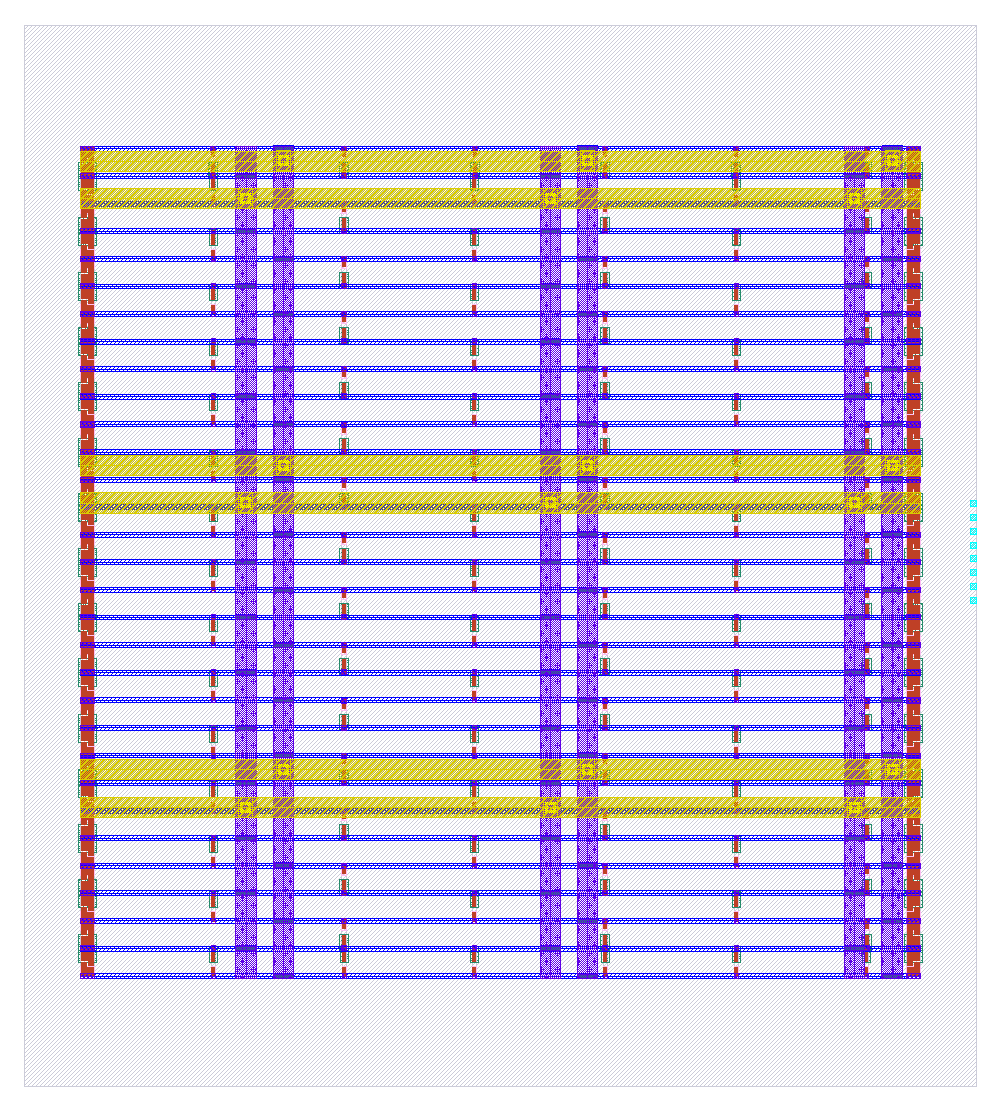

In [32]:
if RUN_STEP_BY_STEP:
    floorplan = Step.factory.get("OpenROAD.Floorplan")(state_in=synthesis.state_out); floorplan.start()
    tdi = Step.factory.get("OpenROAD.TapEndcapInsertion")(state_in=floorplan.state_out); tdi.start()
    ioplace = Step.factory.get("OpenROAD.IOPlacement")(state_in=tdi.state_out); ioplace.start()
    pdn = Step.factory.get("OpenROAD.GeneratePDN")(
        state_in=ioplace.state_out, FP_PDN_VWIDTH=2, FP_PDN_HWIDTH=2, FP_PDN_VPITCH=30, FP_PDN_HPITCH=30)
    pdn.start()
    display(pdn)

Global placement spreads the cells to minimise wire length, and detailed placement legalises them onto the rows.
Clock-tree synthesis then buffers the clock to every flip-flop, 60 of them here because every storage bit is
triplicated.

──────────────────────────────────────────────── Global Placement ─────────────────────────────────────────────────

[03:06:54] VERBOSE  Running 'OpenROAD.GlobalPlacement' at 'librelane_run/16-openroad-globalplacement'… ]8;id=62261;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=639460;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1138\1138]8;;\

[03:06:54] INFO     'PL_TARGET_DENSITY_PCT' not explicitly set, using dynamically calculated       ]8;id=715825;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/openroad.py\openroad.py]8;;\:]8;id=661124;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/openroad.py#1583\1583]8;;\
                    target density: 62.574100…                                                                     

[03:06:54] VERBOSE  Logging subprocess to                                                              ]8;id=413977;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=326936;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/16-openroad-globalplacement/openroad-globalplacement.log'…                      

Reading timing models for corner nom_tt_025C_1v80…

...

Writing layout to '/root/cac/notebook/librelane_run/18-openroad-cts/top_tmr_fb.def'…

Writing timing constraints to '/root/cac/notebook/librelane_run/18-openroad-cts/top_tmr_fb.sdc'…

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[03:07:14] VERBOSE  Running 'KLayout.Render' at '../../../tmp/librelane_klayout_tmp_3wrw0cd9'…         ]8;id=961608;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=617030;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1138\1138]8;;\

[03:07:14] VERBOSE  Logging subprocess to                                                              ]8;id=264401;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=158897;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1338\1338]8;;\
                    '../../../tmp/librelane_klayout_tmp_3wrw0cd9/klayout-render.log'…                              

#### Time Elapsed: 17.08s
#### Views updated:
* Verilog Netlist
* OpenDB Database
* Design Exchange Format
* Design Constraints
* Powered Verilog Netlist
#### Preview:
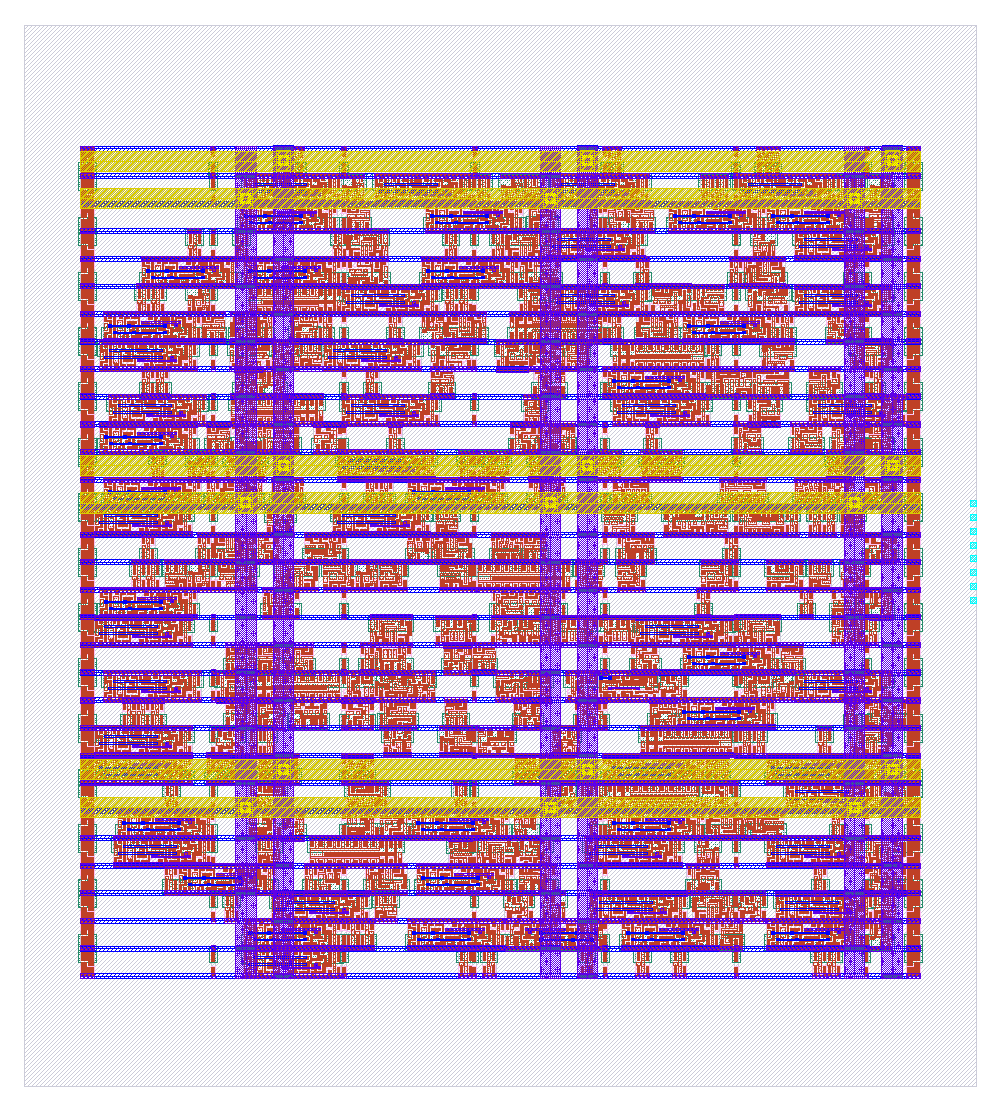

In [33]:
if RUN_STEP_BY_STEP:
    gpl = Step.factory.get("OpenROAD.GlobalPlacement")(state_in=pdn.state_out); gpl.start()
    dpl = Step.factory.get("OpenROAD.DetailedPlacement")(state_in=gpl.state_out); dpl.start()
    cts = Step.factory.get("OpenROAD.CTS")(state_in=dpl.state_out); cts.start()
    display(cts)

Routing, fill insertion, parasitic extraction, static timing analysis and GDS stream-out complete the flow.

───────────────────────────────────────────────── Global Routing ──────────────────────────────────────────────────

[03:07:17] VERBOSE  Running 'OpenROAD.GlobalRouting' at 'librelane_run/19-openroad-globalrouting'…     ]8;id=981153;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=111886;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1138\1138]8;;\

[03:07:17] VERBOSE  Logging subprocess to                                                              ]8;id=424424;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=55969;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1338\1338]8;;\
                    'librelane_run/19-openroad-globalrouting/openroad-globalrouting.log'…                          

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.ciel/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

[INFO] Writing out GDS '/root/cac/notebook/librelane_run/24-klayout-streamout/top_tmr_fb.klayout.gds'…

[INFO] Done.

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[03:08:02] VERBOSE  Running 'KLayout.Render' at '../../../tmp/librelane_klayout_tmp_gn0_r5lp'…         ]8;id=937418;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=750692;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1138\1138]8;;\

[03:08:02] VERBOSE  Logging subprocess to                                                              ]8;id=782317;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py\step.py]8;;\:]8;id=294914;file:///root/nbenv/lib/python3.13/site-packages/librelane/steps/step.py#1338\1338]8;;\
                    '../../../tmp/librelane_klayout_tmp_gn0_r5lp/klayout-render.log'…                              

#### Time Elapsed: 2.94s
#### Views updated:
* GDSII Stream (KLayout)
* GDSII Stream
#### Preview:
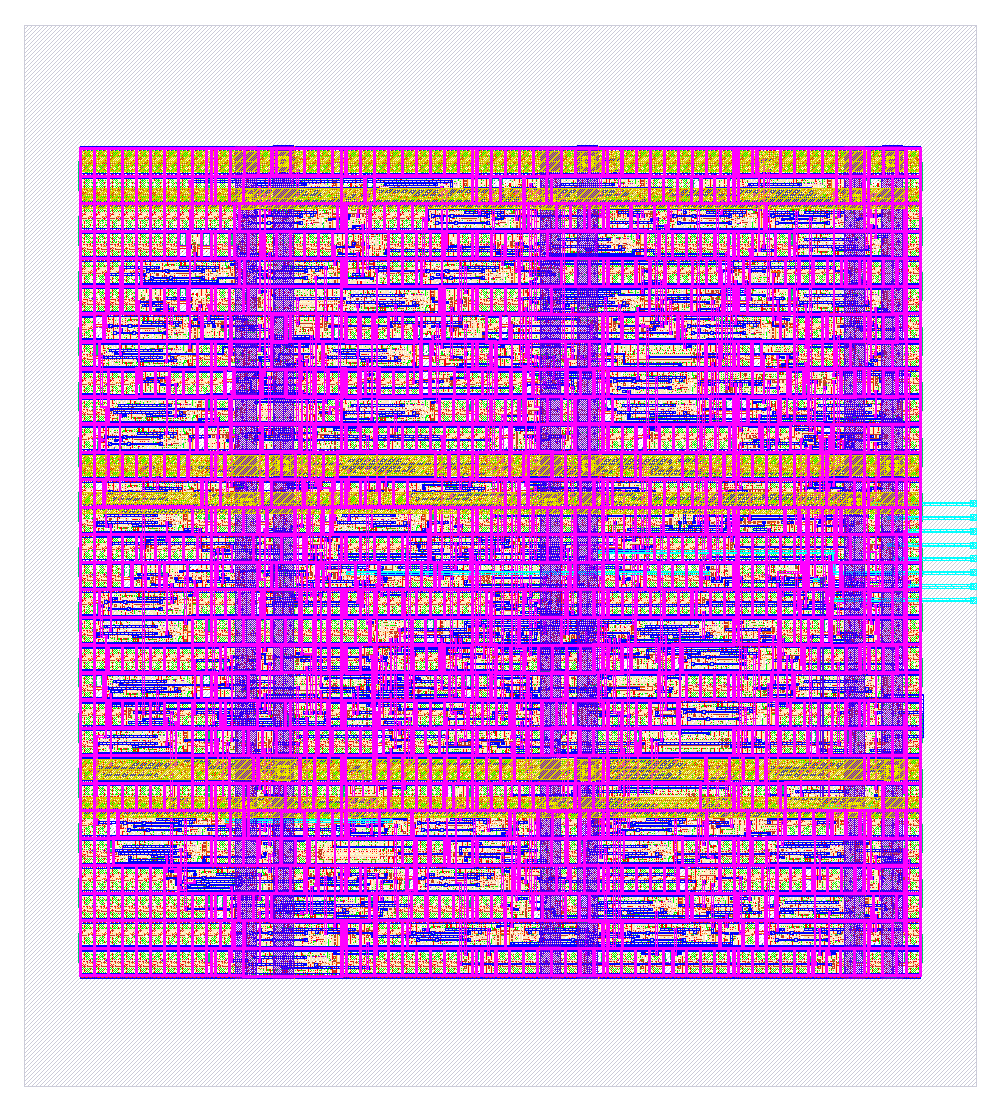

Die area 9821.83 µm², reg-to-reg setup slack 12.733394 ns at a 20 ns clock


In [34]:
if RUN_STEP_BY_STEP:
    grt = Step.factory.get("OpenROAD.GlobalRouting")(state_in=cts.state_out); grt.start()
    drt = Step.factory.get("OpenROAD.DetailedRouting")(state_in=grt.state_out); drt.start()
    fill = Step.factory.get("OpenROAD.FillInsertion")(state_in=drt.state_out); fill.start()
    rcx = Step.factory.get("OpenROAD.RCX")(state_in=fill.state_out); rcx.start()
    sta = Step.factory.get("OpenROAD.STAPostPNR")(state_in=rcx.state_out); sta.start()
    gds = Step.factory.get("KLayout.StreamOut")(state_in=sta.state_out); gds.start()
    display(gds)
    m = sta.state_out.metrics
    print(f"Die area {m.get('design__die__area')} µm², "
          f"reg-to-reg setup slack {m.get('timing__setup_r2r__ws')} ns at a 20 ns clock")

## 8. Implementation cost

Each mode is implemented with LibreLane's `Classic` flow (synthesis, floorplanning, placement, clock-tree synthesis,
routing, parasitic extraction, multi-corner static timing analysis, DRC and LVS) at a relaxed 20 ns clock for area,
and at tighter targets for the frequency measurement in section 9.

Area is reported as logic area: the sum of every standard-cell class except fill, tap, end-cap, decap and antenna
cells. Those scale with the die size the flow chooses rather than with the hardening, so excluding them compares only
the cells the hardening adds.

In [35]:
# Results of a local run, embedded so the notebook works without re-running place-and-route.
# To regenerate: set RUN_PNR = True, run all, then call print_cache() and paste its output here.
PNR_CACHE = [
 {
  "mode": "none",
  "period_ns": 20,
  "seq_cells": 20,
  "logic_area_um2": 1719.149,
  "stdcell_area_um2": 1757.94,
  "die_area_um2": 4706.77,
  "power_total_uW": 121.56202865298837,
  "power_internal_uW": 98.33421790972352,
  "power_switching_uW": 23.225054974318482,
  "power_leakage_uW": 0.0027579289962886833,
  "setup_ws_all_ns": 9.774420660629348,
  "setup_ws_r2r_ns": 13.191502,
  "closed": True
 },
 {
  "mode": "tmr",
  "period_ns": 20,
  "seq_cells": 60,
  "logic_area_um2": 3926.263,
  "stdcell_area_um2": 4046.38,
  "die_area_um2": 9839.71,
  "power_total_uW": 342.41258981637657,
  "power_internal_uW": 265.8431767486036,
  "power_switching_uW": 76.56270463485271,
  "power_leakage_uW": 0.006731256885217363,
  "setup_ws_all_ns": 7.399330246839223,
  "setup_ws_r2r_ns": 11.598752,
  "closed": True
 },
 {
  "mode": "tmr_fb",
  "period_ns": 20,
  "seq_cells": 60,
  "logic_area_um2": 3902.488,
  "stdcell_area_um2": 4022.61,
  "die_area_um2": 9821.83,
  "power_total_uW": 304.5947814825922,
  "power_internal_uW": 244.77348779328167,
  "power_switching_uW": 59.814483392983675,
  "power_leakage_uW": 0.006801493146468829,
  "setup_ws_all_ns": 6.850969763186091,
  "setup_ws_r2r_ns": 12.408153,
  "closed": True
 },
 {
  "mode": "hamming",
  "period_ns": 20,
  "seq_cells": 30,
  "logic_area_um2": 3853.698,
  "stdcell_area_um2": 3977.56,
  "die_area_um2": 10172.3,
  "power_total_uW": 1827.7091439813375,
  "power_internal_uW": 897.8681871667504,
  "power_switching_uW": 929.8336808569729,
  "power_leakage_uW": 0.0072234098702494975,
  "setup_ws_all_ns": 6.5531946168836726,
  "setup_ws_r2r_ns": 6.649907,
  "closed": True
 },
 {
  "mode": "dmr",
  "period_ns": 20,
  "seq_cells": 40,
  "logic_area_um2": 2760.152,
  "stdcell_area_um2": 2843.98,
  "die_area_um2": 7119.97,
  "power_total_uW": 348.0611485429108,
  "power_internal_uW": 248.67855245247483,
  "power_switching_uW": 99.37795402947813,
  "power_leakage_uW": 0.004661606212152947,
  "setup_ws_all_ns": 7.278299946520556,
  "setup_ws_r2r_ns": 12.434311,
  "closed": True
 },
 {
  "mode": "none",
  "period_ns": 8,
  "seq_cells": 20,
  "logic_area_um2": 1719.149,
  "stdcell_area_um2": 1757.94,
  "die_area_um2": 4706.77,
  "power_total_uW": 303.90097526833415,
  "power_internal_uW": 245.83557387813926,
  "power_switching_uW": 58.06262925034389,
  "power_leakage_uW": 0.0027579289962886833,
  "setup_ws_all_ns": 0.1744195948152139,
  "setup_ws_r2r_ns": 0.367714,
  "closed": True
 },
 {
  "mode": "tmr",
  "period_ns": 8,
  "seq_cells": 60,
  "logic_area_um2": 3947.538,
  "stdcell_area_um2": 4067.65,
  "die_area_um2": 9839.71,
  "power_total_uW": 869.0141257829964,
  "power_internal_uW": 675.8589879609644,
  "power_switching_uW": 193.14831297378987,
  "power_leakage_uW": 0.006834463661675727,
  "setup_ws_all_ns": -0.041880278208575164,
  "setup_ws_r2r_ns": 1.056605,
  "closed": True
 },
 {
  "mode": "tmr_fb",
  "period_ns": 8,
  "seq_cells": 60,
  "logic_area_um2": 3942.533,
  "stdcell_area_um2": 4062.65,
  "die_area_um2": 9821.83,
  "power_total_uW": 761.9366515427828,
  "power_internal_uW": 611.8870805948973,
  "power_switching_uW": 150.04255692474544,
  "power_leakage_uW": 0.006976894173504888,
  "setup_ws_all_ns": -0.19582558351380935,
  "setup_ws_r2r_ns": 0.308201,
  "closed": True
 },
 {
  "mode": "hamming",
  "period_ns": 8,
  "seq_cells": 30,
  "logic_area_um2": 4513.081,
  "stdcell_area_um2": 4636.95,
  "die_area_um2": 10172.3,
  "power_total_uW": 5640.0964967906475,
  "power_internal_uW": 2955.8020178228617,
  "power_switching_uW": 2684.286329895258,
  "power_leakage_uW": 0.008066867174250092,
  "setup_ws_all_ns": -2.291366272689212,
  "setup_ws_r2r_ns": -2.291366,
  "closed": False
 },
 {
  "mode": "dmr",
  "period_ns": 8,
  "seq_cells": 40,
  "logic_area_um2": 2827.711,
  "stdcell_area_um2": 2911.54,
  "die_area_um2": 7119.97,
  "power_total_uW": 878.8577397353947,
  "power_internal_uW": 626.9313744269311,
  "power_switching_uW": 251.92167959176004,
  "power_leakage_uW": 0.004740807302283656,
  "setup_ws_all_ns": -0.03950218042257088,
  "setup_ws_r2r_ns": 0.495671,
  "closed": True
 },
 {
  "mode": "none",
  "period_ns": 5,
  "seq_cells": 20,
  "logic_area_um2": 1811.738,
  "stdcell_area_um2": 1850.52,
  "die_area_um2": 4706.77,
  "power_total_uW": 486.6831877734512,
  "power_internal_uW": 393.3281113859266,
  "power_switching_uW": 93.35207141702995,
  "power_leakage_uW": 0.0029999629447274856,
  "setup_ws_all_ns": -0.6124336766624119,
  "setup_ws_r2r_ns": -0.526101,
  "closed": False
 },
 {
  "mode": "tmr",
  "period_ns": 5,
  "seq_cells": 60,
  "logic_area_um2": 4306.63,
  "stdcell_area_um2": 4426.75,
  "die_area_um2": 9839.71,
  "power_total_uW": 1394.0781354904175,
  "power_internal_uW": 1081.5110290423036,
  "power_switching_uW": 312.5598013866693,
  "power_leakage_uW": 0.007337451979338994,
  "setup_ws_all_ns": -2.054016126433978,
  "setup_ws_r2r_ns": -1.405582,
  "closed": False
 },
 {
  "mode": "tmr_fb",
  "period_ns": 5,
  "seq_cells": 60,
  "logic_area_um2": 4142.725,
  "stdcell_area_um2": 4262.84,
  "die_area_um2": 9821.83,
  "power_total_uW": 1221.122220158577,
  "power_internal_uW": 979.0557669475675,
  "power_switching_uW": 242.05920635722578,
  "power_leakage_uW": 0.007271226731830893,
  "setup_ws_all_ns": -2.4604066147533765,
  "setup_ws_r2r_ns": -0.862851,
  "closed": False
 },
 {
  "mode": "hamming",
  "period_ns": 5,
  "seq_cells": 30,
  "logic_area_um2": 4698.254,
  "stdcell_area_um2": 4822.12,
  "die_area_um2": 10172.3,
  "power_total_uW": 9719.48727965355,
  "power_internal_uW": 5173.505749553442,
  "power_switching_uW": 4545.973148196936,
  "power_leakage_uW": 0.008253481453834866,
  "setup_ws_all_ns": -5.297413324608461,
  "setup_ws_r2r_ns": -5.297413,
  "closed": False
 },
 {
  "mode": "dmr",
  "period_ns": 5,
  "seq_cells": 40,
  "logic_area_um2": 2989.123,
  "stdcell_area_um2": 3072.95,
  "die_area_um2": 7119.97,
  "power_total_uW": 1459.286781027913,
  "power_internal_uW": 1038.307324051857,
  "power_switching_uW": 420.9746257402003,
  "power_leakage_uW": 0.004877887871401754,
  "setup_ws_all_ns": -2.239940296644939,
  "setup_ws_r2r_ns": -1.304496,
  "closed": False
 },
 {
  "mode": "none",
  "period_ns": 3.5,
  "seq_cells": 20,
  "logic_area_um2": 1891.815,
  "stdcell_area_um2": 1930.6,
  "die_area_um2": 4706.77,
  "power_total_uW": 696.1456383578479,
  "power_internal_uW": 561.8985160253942,
  "power_switching_uW": 134.24405187834054,
  "power_leakage_uW": 0.0030687778984628267,
  "setup_ws_all_ns": -1.7918667057317152,
  "setup_ws_r2r_ns": -1.6895,
  "closed": False
 },
 {
  "mode": "tmr",
  "period_ns": 3.5,
  "seq_cells": 60,
  "logic_area_um2": 4312.885,
  "stdcell_area_um2": 4433,
  "die_area_um2": 9839.71,
  "power_total_uW": 1999.4392059743404,
  "power_internal_uW": 1551.8444124609232,
  "power_switching_uW": 447.5874884519726,
  "power_leakage_uW": 0.007325328343910087,
  "setup_ws_all_ns": -3.2594088350884665,
  "setup_ws_r2r_ns": -2.735846,
  "closed": False
 },
 {
  "mode": "tmr_fb",
  "period_ns": 3.5,
  "seq_cells": 60,
  "logic_area_um2": 4171.495,
  "stdcell_area_um2": 4291.62,
  "die_area_um2": 9821.83,
  "power_total_uW": 1745.029236190021,
  "power_internal_uW": 1398.6661797389388,
  "power_switching_uW": 346.3556640781462,
  "power_leakage_uW": 0.007367945364933348,
  "setup_ws_all_ns": -3.6610102652333985,
  "setup_ws_r2r_ns": -2.475939,
  "closed": False
 },
 {
  "mode": "hamming",
  "period_ns": 3.5,
  "seq_cells": 30,
  "logic_area_um2": 4668.224,
  "stdcell_area_um2": 4792.1,
  "die_area_um2": 10172.3,
  "power_total_uW": 13708.61567556858,
  "power_internal_uW": 7239.329162985086,
  "power_switching_uW": 6469.278130680323,
  "power_leakage_uW": 0.00818652967637945,
  "setup_ws_all_ns": -6.814068613339175,
  "setup_ws_r2r_ns": -6.814069,
  "closed": False
 },
 {
  "mode": "dmr",
  "period_ns": 3.5,
  "seq_cells": 40,
  "logic_area_um2": 3019.15,
  "stdcell_area_um2": 3102.98,
  "die_area_um2": 7119.97,
  "power_total_uW": 2087.262226268649,
  "power_internal_uW": 1485.0760344415903,
  "power_switching_uW": 602.1811859682202,
  "power_leakage_uW": 0.004923165430881227,
  "setup_ws_all_ns": -3.4275081520903448,
  "setup_ws_r2r_ns": -2.802302,
  "closed": False
 }
]

NON_LOGIC = ("fill", "tap", "endcap", "decap", "antenna")


def read_run_metrics(run_dir):
    """Final metrics, or (if a tight-clock run stopped at a timing check) the post-PnR STA step's metrics."""
    run_dir = Path(run_dir)
    final = run_dir / "final" / "metrics.json"
    if final.is_file():
        return json.loads(final.read_text())
    for step in sorted(run_dir.glob("*-openroad-stapostpnr"), reverse=True):
        for f in ("state_out.json", "or_metrics_out.json"):
            p = step / f
            if p.is_file():
                d = json.loads(p.read_text())
                return d.get("metrics", d)
    return None


def summarise(mode, period, m):
    cls = lambda prefix: sum(v for k, v in m.items() if k.startswith(prefix)
                             and not any(w in k.split(":", 1)[1] for w in NON_LOGIC))
    uw = lambda k: m[k] * 1e6 if m.get(k) is not None else None
    r2r = m.get("timing__setup_r2r__ws")
    return dict(mode=mode, period_ns=period,
                seq_cells=m.get("design__instance__count__class:sequential_cell"),
                logic_area_um2=cls("design__instance__area__class:"),
                stdcell_area_um2=m.get("design__instance__area__stdcell"),
                die_area_um2=m.get("design__die__area"),
                power_total_uW=uw("power__total"), power_internal_uW=uw("power__internal__total"),
                power_switching_uW=uw("power__switching__total"), power_leakage_uW=uw("power__leakage__total"),
                setup_ws_all_ns=m.get("timing__setup__ws"),
                setup_ws_r2r_ns=r2r if r2r is not None and math.isfinite(r2r) else None,
                closed=(r2r is not None and r2r >= 0))


def run_pnr(mode, period):
    d = Path("pnr")
    tag = f"{mode}_T{str(period).replace('.', 'p')}"
    cfg = d / f"config_{tag}.json"
    cfg.write_text(json.dumps({
        "DESIGN_NAME": f"top_{mode}",
        "VERILOG_FILES": ["dir::prot_reg.v", "dir::recovery_fsm.v", f"dir::top_{mode}.v"],
        "CLOCK_PORT": "clk",
        "CLOCK_PERIOD": period,
    }, indent=2))
    with open(d / f"log_{tag}.txt", "w") as log:
        rc = subprocess.run([*LIBRELANE_CMD, "--run-tag", tag, "--overwrite", cfg.name],
                            cwd=d, stdout=log, stderr=subprocess.STDOUT).returncode
    m = read_run_metrics(d / "runs" / tag)
    if m is None:
        print(f"  {tag}: no metrics (exit {rc}); see pnr/log_{tag}.txt")
        return None
    row = summarise(mode, period, m)
    print(f"  {tag}: done (exit {rc}), reg-to-reg slack {row['setup_ws_r2r_ns']}")
    return row


if RUN_PNR and HAVE["LibreLane"]:
    Path("pnr").mkdir(exist_ok=True)
    for f in ["prot_reg.v", "recovery_fsm.v", *[f"top_{t}.v" for t in MODES]]:
        shutil.copy(f, "pnr")
    jobs = [(m, p) for p in PNR_PERIODS_NS for m in MODES]
    print(f"Running {len(jobs)} LibreLane flows on {PNR_WORKERS} workers…")
    t0 = time.time()
    with ThreadPoolExecutor(PNR_WORKERS) as ex:
        results = list(ex.map(lambda j: run_pnr(*j), jobs))
    PNR_CACHE = [r for r in results if r is not None]
    Path("pnr/pnr_results.json").write_text(json.dumps(PNR_CACHE, indent=1))
    print(f"Finished in {(time.time() - t0) / 60:.1f} min")
else:
    print("Using the embedded place-and-route results (RUN_PNR is False).")

pnr = pd.DataFrame(PNR_CACHE)
ref = pnr[pnr.period_ns == 20].set_index("mode").loc[MODES]
base = ref.loc["none"]
cost = pd.DataFrame({
    "Storage flip-flops": ref.seq_cells.astype(int),
    "Logic area (µm²)": ref.logic_area_um2,
    "Area vs NONE": ref.logic_area_um2 / base.logic_area_um2,
    "Die area (µm²)": ref.die_area_um2,
})
table(labelled(cost), caption="Implementation cost at a 20 ns clock (SKY130 HD, LibreLane Classic flow)",
      fmt={"Logic area (µm²)": "{:,.0f}", "Area vs NONE": "{:.2f}×", "Die area (µm²)": "{:,.0f}"})


def print_cache():
    """Print the PNR_CACHE literal to paste into this cell after a fresh RUN_PNR."""
    print("PNR_CACHE = " + json.dumps(PNR_CACHE, indent=1).replace("null", "None")
          .replace("true", "True").replace("false", "False"))

Using the embedded place-and-route results (RUN_PNR is False).


,Storage flip-flops,Logic area (µm²),Area vs NONE,Die area (µm²)
NONE,20,"1,719",1.00×,"4,707"
TMR,60,"3,926",2.28×,"9,840"
TMR_FB,60,"3,902",2.27×,"9,822"
HAMMING,30,"3,854",2.24×,"10,172"
DMR,40,"2,760",1.61×,"7,120"


Storage scales exactly as designed: 20, 60, 60, 30 and 40 flip-flops, matching the storage map used by the fault
campaign. HAMMING stores half as many bits as TMR but costs about the same area, because at these small widths its
encoder and decoder logic consumes the storage saving. Section 13 shows where that changes.

## 9. Maximum clock frequency

Two easily obtained frequency figures are misleading for this comparison. The overall worst slack includes paths from
input pins and to output pins, whose timing is set by LibreLane's assumed external I/O delays rather than by the
design; in this design they are the worst paths, so the figure measures the assumptions instead of the hardening. And
slack at a relaxed clock describes an implementation the tools never tried to make fast, since timing repair stops as
soon as the constraint is met.

The measurement here therefore uses three refinements. It considers register-to-register paths only, because
hardening changes the logic between flip-flops (voters, decoders, encoders). It takes the worst case over LibreLane's
corners, which is the slow corner (ss, 100 °C, 1.60 V), so the figure is guaranteed rather than typical. And it sweeps
the clock target: each mode is implemented at 20, 8, 5 and 3.5 ns, the critical register-to-register delay of each
implementation is the target period minus its slack (valid when the slack is negative), and a mode's maximum
frequency is the best over the sweep.

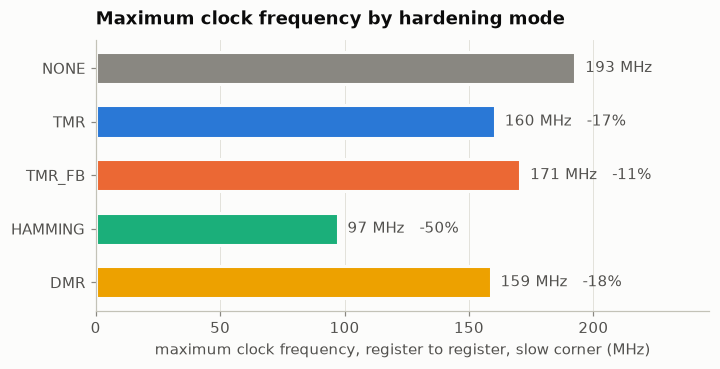

,fmax (MHz),Change vs NONE,Critical path (ns),Best clock target (ns)
NONE,193,–,5.19,3.5
TMR,160,-17%,6.24,3.5
TMR_FB,171,-11%,5.86,5
HAMMING,97,-50%,10.29,8
DMR,159,-18%,6.30,3.5


,20 ns,8 ns,5 ns,3.5 ns
NONE,147,131,181,193
TMR,119,144,156,160
TMR_FB,132,130,171,167
HAMMING,75,97,97,97
DMR,132,133,159,159


In [36]:
def fmax_table(df):
    d = df.dropna(subset=["setup_ws_r2r_ns"]).copy()
    if d.empty:
        return None, None
    d["crit_path_ns"] = d.period_ns - d.setup_ws_r2r_ns
    d["fmax_MHz"] = 1000.0 / d.crit_path_ns
    best = d.loc[d.groupby("mode").fmax_MHz.idxmax()].set_index("mode")
    return d, best


sweep, best = fmax_table(pnr)
if best is None:
    display(Markdown("The embedded results do not include the register-to-register sweep. "
                     "Set `RUN_PNR = True` and re-run sections 8 and 9."))
else:
    best = best.loc[[m for m in MODES if m in best.index]]
    f0 = best.loc["none", "fmax_MHz"]

    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    y = np.arange(len(best))[::-1]
    ax.barh(y, best.fmax_MHz, color=[MODE_COLOR[m] for m in best.index], height=0.6,
            edgecolor=SURFACE, linewidth=2)
    for yi, (m, r) in zip(y, best.iterrows()):
        rel = r.fmax_MHz / f0 - 1
        ax.text(r.fmax_MHz, yi, f"  {r.fmax_MHz:.0f} MHz" + ("" if m == "none" else f"   {rel:+.0%}"),
                va="center", color=INK2)
    ax.set_yticks(y, [MODE_LABEL[m] for m in best.index])
    ax.set_xlabel("maximum clock frequency, register to register, slow corner (MHz)")
    ax.set_xlim(0, best.fmax_MHz.max() * 1.28)
    ax.grid(axis="y", visible=False)
    ax.set_title("Maximum clock frequency by hardening mode")
    save(fig, "fmax"); plt.show()

    out = pd.DataFrame({
        "fmax (MHz)": best.fmax_MHz,
        "Change vs NONE": (best.fmax_MHz / f0 - 1).where(best.index != "none"),
        "Critical path (ns)": best.crit_path_ns,
        "Best clock target (ns)": best.period_ns,
    })
    table(labelled(out), caption="Sign-off maximum frequency (register to register, ss, 100 °C, 1.60 V)",
          fmt={"fmax (MHz)": "{:.0f}", "Change vs NONE": "{:+.0%}", "Critical path (ns)": "{:.2f}",
               "Best clock target (ns)": "{:g}"})

    piv = sweep.pivot(index="mode", columns="period_ns", values="fmax_MHz").loc[best.index]
    piv = piv[sorted(piv.columns, reverse=True)]
    piv.columns = [f"{c:g} ns" for c in piv.columns]
    display(styled(labelled(piv), "{:.0f}",
                   "Achievable frequency (MHz) at each clock target")
            .highlight_max(axis=1, props="font-weight: 700;"))

*Figure 2. Sign-off maximum frequency of each hardening mode, best over the clock-target sweep. In the second table,
the best result for each mode is shown in bold.*

In [37]:
if best is not None:
    h = best.loc["hamming"]
    s20 = sweep[(sweep["mode"] == "none") & (sweep.period_ns == 20)].fmax_MHz.iloc[0]
    protected = best.drop("none").sort_values("fmax_MHz", ascending=False)
    fastest, slowest = protected.index[0], protected.index[-1]
    display(Markdown(
        f"Among the protected modes, {MODE_LABEL[fastest]} keeps the most speed "
        f"({best.loc[fastest, 'fmax_MHz']:.0f} MHz, {best.loc[fastest, 'fmax_MHz'] / f0 - 1:+.0%}) and "
        f"{MODE_LABEL[slowest]} the least ({best.loc[slowest, 'fmax_MHz']:.0f} MHz, "
        f"{best.loc[slowest, 'fmax_MHz'] / f0 - 1:+.0%}). "
        f"HAMMING's critical path stays at about {h.crit_path_ns:.1f} ns however tight the target, because its "
        "syndrome decoder, the controller's next-state logic and its parity encoder sit in series inside the state "
        "feedback loop, and no amount of gate sizing shortens that chain. The voters of TMR and TMR_FB and the "
        "comparator of DMR each add only a level or two of logic.\n\n"
        f"The sweep matters. Measured at the relaxed 20 ns target alone, the unprotected design would have been "
        f"reported at {s20:.0f} MHz rather than {f0:.0f} MHz."))

Among the protected modes, TMR_FB keeps the most speed (171 MHz, -11%) and HAMMING the least (97 MHz, -50%). HAMMING's critical path stays at about 10.3 ns however tight the target, because its syndrome decoder, the controller's next-state logic and its parity encoder sit in series inside the state feedback loop, and no amount of gate sizing shortens that chain. The voters of TMR and TMR_FB and the comparator of DMR each add only a level or two of logic.

The sweep matters. Measured at the relaxed 20 ns target alone, the unprotected design would have been reported at 147 MHz rather than 193 MHz.

## 10. Reliability: the fault-injection campaign

The campaign simulates thousands of complete flights per mode with upsets injected into the storage flip-flops.
Flight profiles are randomised: liftoff, burnout, apogee and main-deploy times vary from flight to flight. Every mode
flies the same flights and is struck at the same times (common random numbers), so differences between modes are not
noise from different flights. Strikes land uniformly over the storage map (every bit of `state`, `timer` and `armed`,
in every copy), so a mode with more flip-flops receives proportionally more of them. Before any statistics, every mode
must fly 50 random flights nominally without faults, or the campaign stops.

Each flight is classified into one of four outcomes:

| Outcome | Meaning |
|:--|:--|
| Nominal | both parachutes fired on time with a full-length pulse |
| Fail-silent | a fault was detected, the controller entered `SAFE`, and the backup altimeter takes over |
| Loss, early | a pyro fired before its event, deploying a parachute at speed |
| Loss, missed | a pyro never fired, fired late or briefly, or the controller locked up undetected |

Two experiments are run. In the single-upset experiment each flight receives exactly one upset, at a random cycle and
a random storage bit. In the accelerated experiment each storage bit is upset at a rate λ per flight, so a flight
receives k ~ Poisson(λ × storage bits) upsets. As in accelerated life testing, high rates separate modes that all look
perfect at realistic rates. Proportions carry 95% Wilson confidence intervals, which remain meaningful when no failures
are observed.

In [38]:
%%writefile tb_campaign.v
// tb_campaign.v -- fault-injection campaign testbench (driven by fault_campaign.py)
//
// Runs many flights in ONE simulation. Each line of the schedule file is a trial:
//
//   t_launch t_burnout t_apogee t_main t_end  k  c1 b1  c2 b2 ... ck bk
//
//   t_*  : cycle numbers of the flight events (cycle 0 = start of trial)
//   k    : number of upsets in this flight
//   ci bi: flip storage bit bi (flat index, see below) at cycle ci
//
// For each trial one result line is written to the output file:
//
//   trial d_first d_cycles m_first m_cycles final_state err_first err_cycles
//
//   d_first / m_first : first cycle drogue / main fired (-1 = never)
//   d_cycles/ m_cycles: total cycles the output was high (pulse length)
//
// Flat storage-bit index: registers in the order state, timer, armed; within
// each register copy 0, then copy 1, ...; within each copy bit 0 upward.
// Run with +probe to print this layout instead of simulating.
//
// Compile per mode, NCOPY = number of storage copies (NONE/HAMMING 1, DMR 2, TMR* 3),
// optional -DGATE_PYRO=0 for the ungated DMR variant:
//   iverilog -g2012 -DMODE_STR='"TMR"' -DNCOPY=3 -o sim prot_reg.v recovery_fsm.v tb_campaign.v
//   vvp -n sim +faults=sched.txt +out=results.txt

`timescale 1ns/1ps
`ifndef MODE_STR
  `define MODE_STR "NONE"
`endif
`ifndef NCOPY
  `define NCOPY 1
`endif
`ifndef GATE_PYRO
  `define GATE_PYRO 1
`endif

module tb;
    localparam integer LOCKOUT  = 50;
    localparam integer BACKUP   = 400;
    localparam integer FIRE_CYC = 10;
    localparam integer RST_CYC  = 3;
    localparam integer MAXK     = 64;

    reg clk = 0, rst = 1, launch = 0, apogee = 0, below_main = 0;
    wire drogue_fire, main_fire, err;
    always #5 clk = ~clk;

    recovery_fsm #(
        .MODE(`MODE_STR), .LOCKOUT(LOCKOUT[15:0]), .BACKUP(BACKUP[15:0]),
        .FIRE_CYC(FIRE_CYC[15:0]), .GATE_PYRO(`GATE_PYRO)
    ) dut (
        .clk(clk), .rst(rst), .launch(launch), .apogee(apogee),
        .below_main(below_main), .drogue_fire(drogue_fire),
        .main_fire(main_fire), .err(err)
    );

    // ---------------- storage layout ----------------
    integer sw, tw, aw, nc, nbits;

    task flip_state(input integer c, input integer b);
        case (c)
            0: dut.u_state.g.r0[b] = ~dut.u_state.g.r0[b];
`ifdef HAS_R1
            1: dut.u_state.g.r1[b] = ~dut.u_state.g.r1[b];
`endif
`ifdef HAS_R2
            2: dut.u_state.g.r2[b] = ~dut.u_state.g.r2[b];
`endif
        endcase
    endtask

    task flip_timer(input integer c, input integer b);
        case (c)
            0: dut.u_timer.g.r0[b] = ~dut.u_timer.g.r0[b];
`ifdef HAS_R1
            1: dut.u_timer.g.r1[b] = ~dut.u_timer.g.r1[b];
`endif
`ifdef HAS_R2
            2: dut.u_timer.g.r2[b] = ~dut.u_timer.g.r2[b];
`endif
        endcase
    endtask

    task flip_armed(input integer c, input integer b);
        case (c)
            0: dut.u_armed.g.r0[b] = ~dut.u_armed.g.r0[b];
`ifdef HAS_R1
            1: dut.u_armed.g.r1[b] = ~dut.u_armed.g.r1[b];
`endif
`ifdef HAS_R2
            2: dut.u_armed.g.r2[b] = ~dut.u_armed.g.r2[b];
`endif
        endcase
    endtask

    task flip(input integer idx);
        integer i;
        begin
            i = idx;
            if (i < sw * nc) flip_state(i / sw, i % sw);
            else begin
                i = i - sw * nc;
                if (i < tw * nc) flip_timer(i / tw, i % tw);
                else begin
                    i = i - tw * nc;
                    flip_armed(i / aw, i % aw);
                end
            end
        end
    endtask

    // ---------------- campaign ----------------
    reg [8*512-1:0] fname, oname;
    integer fd, fo, n, trial, cyc, j, k;
    integer t_launch, t_burn, t_apogee, t_main, t_end;
    integer fc [0:MAXK-1];
    integer fb [0:MAXK-1];
    integer d_first, d_cnt, m_first, m_cnt, e_first, e_cnt;

    initial begin
        sw = $bits(dut.u_state.g.r0);
        tw = $bits(dut.u_timer.g.r0);
        aw = $bits(dut.u_armed.g.r0);
        nc = `NCOPY;
        nbits = (sw + tw + aw) * nc;

        if ($test$plusargs("probe")) begin
            $display("NBITS %0d", nbits);
            $display("SEG state %0d %0d %0d", 0,                  sw, nc);
            $display("SEG timer %0d %0d %0d", sw * nc,            tw, nc);
            $display("SEG armed %0d %0d %0d", (sw + tw) * nc,     aw, nc);
            $finish;
        end

        if (!$value$plusargs("faults=%s", fname) || !$value$plusargs("out=%s", oname)) begin
            $display("usage: vvp sim +faults=<schedule> +out=<results>  (or +probe)");
            $finish;
        end
        fd = $fopen(fname, "r");
        fo = $fopen(oname, "w");
        if (fd == 0 || fo == 0) begin
            $display("cannot open schedule or output file");
            $finish;
        end

        trial = 0;
        while ($fscanf(fd, "%d %d %d %d %d %d",
                       t_launch, t_burn, t_apogee, t_main, t_end, k) == 6) begin
            for (j = 0; j < k; j = j + 1)
                n = $fscanf(fd, "%d %d", fc[j], fb[j]);

            d_first = -1; d_cnt = 0; m_first = -1; m_cnt = 0;
            e_first = -1; e_cnt = 0;

            for (cyc = 0; cyc < t_end; cyc = cyc + 1) begin
                @(negedge clk);
                // inputs for the next rising edge
                rst        = (cyc < RST_CYC);
                launch     = (cyc >= t_launch && cyc < t_burn);
                apogee     = (cyc >= t_apogee && cyc < t_apogee + 5);
                below_main = (cyc >= t_main);
                // upsets scheduled for this cycle
                for (j = 0; j < k; j = j + 1)
                    if (fc[j] == cyc) flip(fb[j]);
                // outputs are combinational from the stored state
                #1;
                if (drogue_fire) begin if (d_first < 0) d_first = cyc; d_cnt = d_cnt + 1; end
                if (main_fire)   begin if (m_first < 0) m_first = cyc; m_cnt = m_cnt + 1; end
                if (err)         begin if (e_first < 0) e_first = cyc; e_cnt = e_cnt + 1; end
            end

            $fdisplay(fo, "%0d %0d %0d %0d %0d %0d %0d %0d",
                      trial, d_first, d_cnt, m_first, m_cnt, dut.state, e_first, e_cnt);
            trial = trial + 1;
            rst = 1;                         // hold reset between trials
        end

        $fclose(fd);
        $fclose(fo);
        $finish;
    end
endmodule

Overwriting tb_campaign.v


In [39]:
%%writefile fault_campaign.py
#!/usr/bin/env python3
"""
fault_campaign.py -- single-event-upset fault-injection campaign for prot_reg designs.

Two experiments, both on the recovery FSM in every hardening mode:

  1. SINGLE-STRIKE (architectural vulnerability):
     one upset per flight, at a uniformly random cycle and a uniformly random
     storage bit. Gives P(outcome | one strike) per mode, and which register
     the dangerous strikes landed in.

  2. MULTI-STRIKE MONTE CARLO (accumulation):
     each storage bit is upset with rate LAMBDA per flight, so a flight sees
     k ~ Poisson(LAMBDA * storage_bits) upsets. Swept over LAMBDA. This is
     where repair matters: plain TMR lets faults pile up in held registers.

Every flight also gets a randomised profile (launch, burnout, apogee and
main-deploy times), and all modes see the SAME profiles and the same strike
times (common random numbers), so differences between modes are not noise
from different flights.

Outcomes:
  NOMINAL     both chutes fired on time with a full pulse
  SAFE        a fault was detected and the controller went fail-silent
              (DMR only); recovery is handed to the backup altimeter
  LOSS_EARLY  a pyro fired before its event (deployment at speed)
  LOSS_MISSED a pyro never fired, fired late, or fired a short pulse

Usage (Icarus Verilog required: iverilog, vvp):
  python3 fault_campaign.py                    # defaults: 3000 single, 1000 per MC point
  python3 fault_campaign.py --trials 500 --mc-trials 0      # single-strike only, fast
  python3 fault_campaign.py --out results/ --seed 7

Outputs (in --out):
  reliability.csv   per mode: storage bits, outcome probabilities + 95% CI,
                    and vulnerability relative to NONE
  by_register.csv   single-strike outcomes split by the register that was hit
  mc_sweep.csv      multi-strike: P(loss) vs upset rate per mode
  trials_single.csv every single-strike trial (for inspection)

Standard library only.
"""
import argparse
import csv
import math
import random
import shutil
import subprocess
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent

# mode tag -> (MODE parameter, storage copies, extra compile defines)
MODES = {
    "none":        ("NONE",    1, []),
    "tmr":         ("TMR",     3, []),
    "tmr_fb":      ("TMR_FB",  3, []),
    "hamming":     ("HAMMING", 1, []),
    "dmr":         ("DMR",     2, []),
    # DMR without output gating: pyros can fire for one cycle before the FSM
    # reaches SAFE. Kept to show the flaw the campaign found. Not run by default.
    "dmr_ungated": ("DMR",     2, ["-DGATE_PYRO=0"]),
}
DEFAULT_MODES = ["none", "tmr", "tmr_fb", "hamming", "dmr"]

# must match tb_campaign.v / recovery_fsm.v
RST_CYC  = 3
FIRE_CYC = 10
S_SAFE   = 6
TOL      = 3            # cycles of slack allowed on a deployment
MAXK     = 64

OUTCOMES = ["NOMINAL", "SAFE", "LOSS_EARLY", "LOSS_MISSED"]

DEFAULT_LAMBDAS = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]


# ---------------------------------------------------------------- simulation

def build(mode_tag, build_dir, sources):
    mode, ncopy, extra = MODES[mode_tag]
    defs = [f'-DMODE_STR="{mode}"', f"-DNCOPY={ncopy}", *extra]
    if ncopy >= 2:
        defs.append("-DHAS_R1")
    if ncopy >= 3:
        defs.append("-DHAS_R2")
    out = build_dir / f"sim_{mode_tag}"
    subprocess.run(["iverilog", "-g2012", *defs, "-o", str(out), *map(str, sources)],
                   check=True)
    return out


def probe(sim):
    """Return (storage_bits, [(register, offset, width, copies), ...])."""
    txt = subprocess.run(["vvp", "-n", str(sim), "+probe"], check=True,
                         capture_output=True, text=True).stdout
    nbits, segs = None, []
    for line in txt.splitlines():
        f = line.split()
        if f and f[0] == "NBITS":
            nbits = int(f[1])
        elif f and f[0] == "SEG":
            segs.append((f[1], int(f[2]), int(f[3]), int(f[4])))
    return nbits, segs


def register_of(bit, segs):
    """Map a flat storage-bit index to 'register.copyN'."""
    for name, off, width, copies in segs:
        if off <= bit < off + width * copies:
            return name, (bit - off) // width
    return "?", -1


def simulate(sim, schedule, work, tag):
    """schedule: list of (profile, [(cycle, bit), ...]). Returns result rows."""
    sched = work / f"sched_{tag}.txt"
    res = work / f"res_{tag}.txt"
    with sched.open("w") as f:
        for (tl, tb, ta, tm, te), faults in schedule:
            flat = " ".join(f"{c} {b}" for c, b in faults)
            f.write(f"{tl} {tb} {ta} {tm} {te} {len(faults)} {flat}\n")
    subprocess.run(["vvp", "-n", str(sim), f"+faults={sched}", f"+out={res}"],
                   check=True, capture_output=True)
    rows = []
    for line in res.read_text().splitlines():
        t, df, dc, mf, mc, st, ef, ec = map(int, line.split())
        rows.append(dict(trial=t, d_first=df, d_cycles=dc, m_first=mf,
                         m_cycles=mc, state=st, err_first=ef, err_cycles=ec))
    if len(rows) != len(schedule):
        sys.exit(f"{tag}: simulator returned {len(rows)} results for {len(schedule)} trials")
    return rows


# ---------------------------------------------------------------- flights & faults

def make_profiles(rng, n):
    """Randomised flight timelines (cycles). LOCKOUT is 50 cycles after launch."""
    profs = []
    for _ in range(n):
        tl = rng.randint(10, 20)              # liftoff
        tb = tl + rng.randint(15, 30)         # motor burnout
        ta = tl + rng.randint(80, 110)        # apogee (always after lockout)
        tm = ta + rng.randint(60, 100)        # descend below main altitude
        te = tm + 40                          # landed, end of trial
        profs.append((tl, tb, ta, tm, te))
    return profs


def poisson(rng, mean):
    """Knuth's method; fine for the small means used here."""
    if mean <= 0:
        return 0
    if mean > 30:                              # normal approximation
        return max(0, round(rng.gauss(mean, math.sqrt(mean))))
    limit, k, p = math.exp(-mean), 0, 1.0
    while True:
        p *= rng.random()
        if p <= limit:
            return k
        k += 1


def classify(r, prof):
    _, _, ta, tm, _ = prof
    d_due, m_due = ta + 1, tm + 1              # first fire cycle with no fault
    if (0 <= r["d_first"] < d_due) or (0 <= r["m_first"] < m_due):
        return "LOSS_EARLY"
    d_ok = r["d_first"] >= 0 and r["d_first"] <= d_due + TOL and r["d_cycles"] >= FIRE_CYC
    m_ok = r["m_first"] >= 0 and r["m_first"] <= m_due + TOL and r["m_cycles"] >= FIRE_CYC
    if d_ok and m_ok:
        return "NOMINAL"
    # SAFE needs the fault to have been DETECTED. In unprotected modes a flip
    # can land the state register on the SAFE encoding by accident; that is
    # an undetected lock-up, i.e. a loss.
    if r["state"] == S_SAFE and r["err_first"] >= 0:
        return "SAFE"
    return "LOSS_MISSED"


# ---------------------------------------------------------------- statistics

def wilson(k, n, z=1.96):
    """95% Wilson score interval for a proportion."""
    if n == 0:
        return (float("nan"),) * 3
    p = k / n
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return p, max(0.0, c - h), min(1.0, c + h)


# ---------------------------------------------------------------- experiments

def run(args):
    for tool in ("iverilog", "vvp"):
        if shutil.which(tool) is None:
            sys.exit(f"{tool} not found: install Icarus Verilog "
                     "(Ubuntu/Colab: apt-get install -y iverilog)")

    src = [args.src / "prot_reg.v", args.src / "recovery_fsm.v", args.src / "tb_campaign.v"]
    out = args.out
    work = out / "work"
    work.mkdir(parents=True, exist_ok=True)

    modes = args.modes
    sims, layout = {}, {}
    for m in modes:
        sims[m] = build(m, work, src)
        layout[m] = probe(sims[m])
        print(f"built {m:8s} storage bits = {layout[m][0]}")

    # ---- sanity: no faults -> every mode must fly nominally ----
    rng = random.Random(args.seed)
    profiles = make_profiles(rng, 50)
    for m in modes:
        rows = simulate(sims[m], [(p, []) for p in profiles], work, f"{m}_clean")
        bad = [classify(r, p) for r, p in zip(rows, profiles) if classify(r, p) != "NOMINAL"]
        if bad:
            sys.exit(f"{m}: {len(bad)} fault-free flights were not nominal -- design or "
                     "testbench is broken, aborting")
    print("fault-free check: all modes nominal on 50 random flights")

    # ---- experiment 1: single strike ----
    rng = random.Random(args.seed + 1)
    profiles = make_profiles(rng, args.trials)
    # common random numbers: same strike time and same uniform draw per trial
    draws = [(rng.randint(RST_CYC, p[4] - 1), rng.random()) for p in profiles]

    summary, by_reg, trial_rows = [], {}, []
    for m in modes:
        nbits, segs = layout[m]
        sched = [(p, [(c, min(int(u * nbits), nbits - 1))]) for p, (c, u) in zip(profiles, draws)]
        rows = simulate(sims[m], sched, work, f"{m}_single")
        counts = dict.fromkeys(OUTCOMES, 0)
        for (p, faults), r in zip(sched, rows):
            o = classify(r, p)
            counts[o] += 1
            reg, copy = register_of(faults[0][1], segs)
            key = (m, reg)
            by_reg.setdefault(key, dict.fromkeys(OUTCOMES, 0))[o] += 1
            trial_rows.append(dict(mode=m, trial=r["trial"], cycle=faults[0][0],
                                   bit=faults[0][1], register=reg, copy=copy,
                                   outcome=o, err_cycles=r["err_cycles"]))
        n = args.trials
        loss = counts["LOSS_EARLY"] + counts["LOSS_MISSED"]
        p_loss, lo, hi = wilson(loss, n)
        row = dict(mode=m, storage_bits=nbits, trials=n,
                   p_nominal=counts["NOMINAL"] / n, p_safe=counts["SAFE"] / n,
                   p_loss_early=counts["LOSS_EARLY"] / n,
                   p_loss_missed=counts["LOSS_MISSED"] / n,
                   p_loss=p_loss, p_loss_ci_lo=lo, p_loss_ci_hi=hi,
                   # strikes scale with storage bits: losses per flight per unit
                   # per-bit upset rate (small-rate limit)
                   vulnerability=nbits * p_loss,
                   vulnerability_ci_lo=nbits * lo, vulnerability_ci_hi=nbits * hi)
        summary.append(row)
        print(f"single  {m:8s} nominal {row['p_nominal']:6.1%}  safe {row['p_safe']:6.1%}  "
              f"loss {p_loss:6.2%} [{lo:.2%}, {hi:.2%}]")

    base = next((r for r in summary if r["mode"] == "none"), None)
    for r in summary:
        r["vulnerability_rel"] = (r["vulnerability"] / base["vulnerability"]
                                  if base and base["vulnerability"] > 0 else None)

    # ---- experiment 2: multi-strike Monte Carlo ----
    mc = []
    if args.mc_trials > 0:
        rng = random.Random(args.seed + 2)
        profiles = make_profiles(rng, args.mc_trials)
        # per-trial uniforms reused by every mode and rate (common random numbers)
        trial_seeds = [rng.random() for _ in profiles]
        for lam in args.lambdas:
            for m in modes:
                nbits, _ = layout[m]
                sched = []
                for i, p in enumerate(profiles):
                    r = random.Random(f"{trial_seeds[i]}-{lam}-{nbits}")
                    k = min(poisson(r, lam * nbits), MAXK)
                    faults = [(r.randint(RST_CYC, p[4] - 1), r.randrange(nbits))
                              for _ in range(k)]
                    sched.append((p, faults))
                rows = simulate(sims[m], sched, work, f"{m}_mc")
                counts = dict.fromkeys(OUTCOMES, 0)
                for (p, _), rr in zip(sched, rows):
                    counts[classify(rr, p)] += 1
                n = args.mc_trials
                loss = counts["LOSS_EARLY"] + counts["LOSS_MISSED"]
                p_loss, lo, hi = wilson(loss, n)
                mean_k = sum(len(f) for _, f in sched) / n
                mc.append(dict(mode=m, upsets_per_bit=lam, mean_upsets=mean_k,
                               trials=n, p_nominal=counts["NOMINAL"] / n,
                               p_safe=counts["SAFE"] / n, p_loss=p_loss,
                               p_loss_ci_lo=lo, p_loss_ci_hi=hi))
            line = "  ".join(f"{r['mode']} {r['p_loss']:6.1%}" for r in mc[-len(modes):])
            print(f"MC  lambda={lam:<6} P(loss): {line}")

    # ---- write ----
    def write(name, rows):
        if not rows:
            return
        with (out / name).open("w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            w.writeheader()
            w.writerows(rows)

    write("reliability.csv", summary)
    write("by_register.csv", [dict(mode=m, register=reg, trials=sum(c.values()),
                                   **{k.lower(): v for k, v in c.items()})
                              for (m, reg), c in sorted(by_reg.items())])
    write("mc_sweep.csv", mc)
    write("trials_single.csv", trial_rows)
    print(f"\nresults -> {out}/  (reliability.csv, by_register.csv, mc_sweep.csv, trials_single.csv)")


def main():
    ap = argparse.ArgumentParser(description=__doc__,
                                 formatter_class=argparse.RawDescriptionHelpFormatter)
    ap.add_argument("--src", type=Path, default=HERE,
                    help="folder with prot_reg.v, recovery_fsm.v, tb_campaign.v")
    ap.add_argument("--out", type=Path, default=Path("fault_results"))
    ap.add_argument("--trials", type=int, default=3000, help="single-strike flights per mode")
    ap.add_argument("--mc-trials", type=int, default=1000, help="flights per mode per MC rate")
    ap.add_argument("--lambdas", type=float, nargs="+", default=DEFAULT_LAMBDAS,
                    help="per-bit upset rates per flight for the MC sweep")
    ap.add_argument("--modes", nargs="+", default=DEFAULT_MODES, choices=list(MODES),
                    help="modes to test (add dmr_ungated to reproduce the gating flaw)")
    ap.add_argument("--seed", type=int, default=1)
    args = ap.parse_args()
    run(args)


if __name__ == "__main__":
    main()

Overwriting fault_campaign.py


In [40]:
if HAVE["Icarus Verilog"]:
    t0 = time.time()
    proc = subprocess.run([sys.executable, "fault_campaign.py", "--out", "fault_results",
                           "--trials", str(TRIALS_SINGLE), "--mc-trials", str(TRIALS_MC),
                           "--seed", str(SEED), "--modes", *MODES, "dmr_ungated"],
                          capture_output=True, text=True)
    if proc.returncode != 0:
        print(proc.stdout[-3000:], proc.stderr[-3000:])
        raise RuntimeError("fault campaign failed")
    n_rates = len(pd.read_csv("fault_results/mc_sweep.csv").upsets_per_bit.unique())
    print(f"Campaign complete in {time.time() - t0:.0f} s: {TRIALS_SINGLE:,} single-upset flights and "
          f"{TRIALS_MC * n_rates:,} accelerated flights per mode, across {len(MODES) + 1} modes.")
rel = pd.read_csv("fault_results/reliability.csv").set_index("mode")
mc = pd.read_csv("fault_results/mc_sweep.csv")
byreg = pd.read_csv("fault_results/by_register.csv")

Campaign complete in 219 s: 3,000 single-upset flights and 6,000 accelerated flights per mode, across 6 modes.


### 10.1 The effect of a single upset

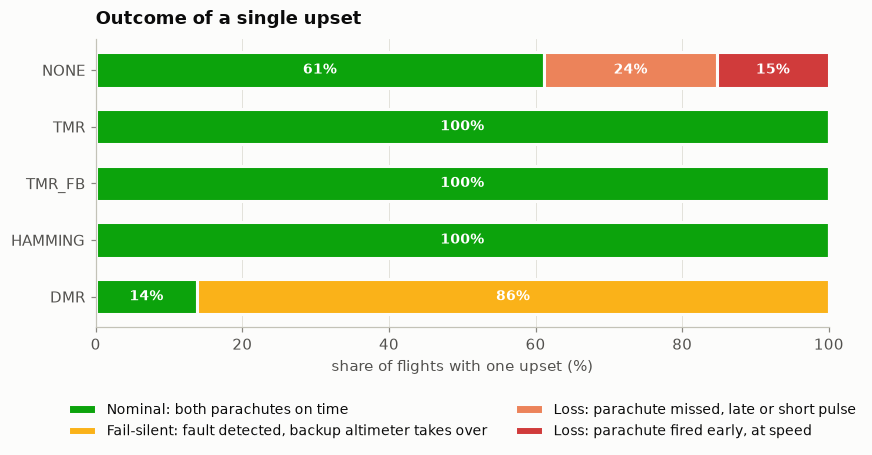

,Storage bits,P(loss),95% CI,P(fail-silent)
NONE,20,38.83%,37.10% – 40.59%,0.0%
TMR,60,0.00%,0.00% – 0.13%,0.0%
TMR_FB,60,0.00%,0.00% – 0.13%,0.0%
HAMMING,30,0.00%,0.00% – 0.13%,0.0%
DMR,40,0.00%,0.00% – 0.13%,86.2%


In [41]:
order = MODES
fig, ax = plt.subplots(figsize=(8.6, 3.4))
y = np.arange(len(order))[::-1]
left = np.zeros(len(order))
cols = {"NOMINAL": "p_nominal", "SAFE": "p_safe", "LOSS_MISSED": "p_loss_missed", "LOSS_EARLY": "p_loss_early"}
for o, c in cols.items():
    v = rel.loc[order, c].values * 100
    ax.barh(y, v, left=left, color=OUTCOME_COLOR[o], height=0.62, edgecolor=SURFACE, linewidth=2,
            label=OUTCOME_LABEL[o])
    for yi, l, w in zip(y, left, v):
        if w >= 8:
            ax.text(l + w / 2, yi, f"{w:.0f}%", ha="center", va="center", color="#ffffff",
                    fontsize=9, fontweight="bold")
    left += v
ax.set_yticks(y, [MODE_LABEL[m] for m in order])
ax.set_xlim(0, 100); ax.set_xlabel("share of flights with one upset (%)")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=9)
ax.set_title("Outcome of a single upset")
save(fig, "single_strike_outcomes"); plt.show()

t = rel.loc[order]
single = pd.DataFrame({
    "Storage bits": t.storage_bits.astype(int),
    "P(loss)": t.p_loss,
    "95% CI": [f"{lo:.2%} – {hi:.2%}" for lo, hi in zip(t.p_loss_ci_lo, t.p_loss_ci_hi)],
    "P(fail-silent)": t.p_safe,
})
table(labelled(single), caption=f"Single-upset outcome, {TRIALS_SINGLE:,} flights per mode",
      fmt={"P(loss)": "{:.2%}", "P(fail-silent)": "{:.1%}"})

*Figure 3. Outcome of flights that received exactly one upset, by hardening mode.*

About four in ten single upsets lose an unprotected rocket. Every protected mode recorded zero losses, and the upper
confidence bound places the true rate below about 0.13% per upset. DMR achieves this by giving up: most upsets shut the
primary controller down, which is safe but leaves the backup altimeter to fly most of those missions.

### 10.2 Which register matters

The single-upset results for the unprotected design can be split by the register that was hit.

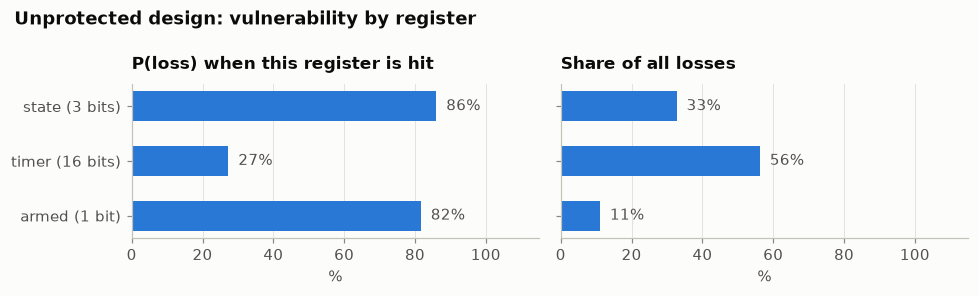

,Bits,Upsets landed,Early deployments,Missed deployments
state,3,443,3,378
timer,16,"2,399",455,200
armed,1,158,0,129


In [42]:
nr = byreg[byreg["mode"] == "none"].set_index("register").loc[["state", "timer", "armed"]]
nr["loss"] = nr.loss_early + nr.loss_missed
nr["p_loss_given_hit"] = nr.loss / nr.trials
nr["share_of_losses"] = nr.loss / nr.loss.sum()
nr["bits"] = [3, 16, 1]

fig, axes = plt.subplots(1, 2, figsize=(9, 2.7), sharey=True)
y = np.arange(3)[::-1]
for ax, col, title in ((axes[0], "p_loss_given_hit", "P(loss) when this register is hit"),
                       (axes[1], "share_of_losses", "Share of all losses")):
    ax.barh(y, nr[col] * 100, color=MODE_COLOR["tmr"], height=0.55)
    for yi, v in zip(y, nr[col] * 100):
        ax.text(v, yi, f"  {v:.0f}%", va="center", color=INK2)
    ax.set_xlim(0, 115); ax.grid(axis="y", visible=False); ax.set_title(title, fontsize=11)
    ax.set_xlabel("%")
axes[0].set_yticks(y, [f"{r} ({b} bit{'s' if b > 1 else ''})" for r, b in zip(nr.index, nr.bits)])
fig.suptitle("Unprotected design: vulnerability by register", x=0.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "by_register"); plt.show()

regs = pd.DataFrame({
    "Bits": nr.bits, "Upsets landed": nr.trials, "Early deployments": nr.loss_early,
    "Missed deployments": nr.loss_missed,
})
table(regs, caption="Unprotected design: single-upset losses by register", fmt="{:,}")

*Figure 4. Unprotected design: probability of mission loss given an upset in each register (left), and each
register's share of all losses (right).*

A hit on `state` or `armed` almost always loses the flight. The timer is less sensitive per hit, because a low-order
flip only shifts a deadline by a few cycles, but it holds most of the bits, so it causes most of the losses and nearly
all of the early deployments: a flipped high-order bit makes the controller believe that the apogee lockout or the
backup timer has already expired.

### 10.3 Fault accumulation

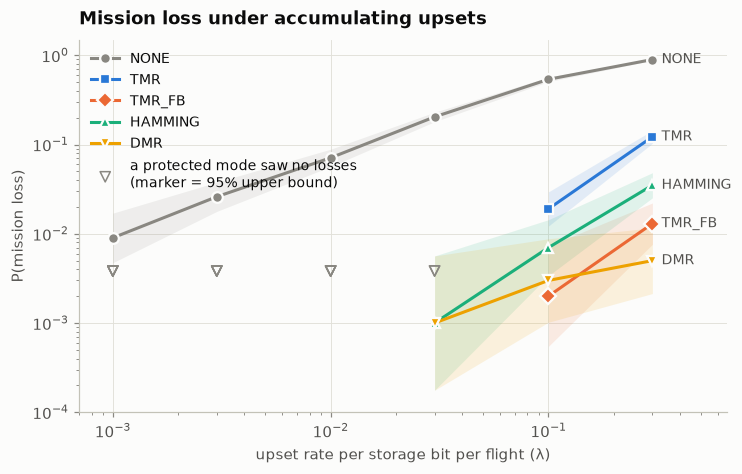

,NONE,TMR,TMR_FB,HAMMING,DMR
λ = 0.001,0.9%,0.0%,0.0%,0.0%,0.0%
λ = 0.003,2.6%,0.0%,0.0%,0.0%,0.0%
λ = 0.01,7.1%,0.0%,0.0%,0.0%,0.0%
λ = 0.03,20.4%,0.0%,0.0%,0.1%,0.1%
λ = 0.1,53.8%,1.9%,0.2%,0.7%,0.3%
λ = 0.3,89.6%,12.2%,1.3%,3.5%,0.5%


In [43]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
floor = 1e-4
zero_x, zero_y = [], []
for m in order:
    d = mc[mc["mode"] == m].sort_values("upsets_per_bit")
    x, p = d.upsets_per_bit.values, d.p_loss.values
    lo, hi = d.p_loss_ci_lo.values, d.p_loss_ci_hi.values
    pos = p > 0
    ax.plot(x[pos], p[pos], color=MODE_COLOR[m], marker=MODE_MARKER[m], markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=MODE_LABEL[m], zorder=3)
    ax.fill_between(x[pos], np.maximum(lo[pos], floor), hi[pos], color=MODE_COLOR[m], alpha=0.12, lw=0)
    zero_x.extend(x[~pos]); zero_y.extend(hi[~pos])
    if pos.any():
        ax.annotate(MODE_LABEL[m], (x[pos][-1], p[pos][-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", color=INK2, fontsize=9)
# the same trial count everywhere means every zero-loss point has the same upper bound: draw it once, neutral
ax.scatter(zero_x, zero_y, marker="v", facecolor="none", edgecolor=MUTED, s=45, zorder=2,
           label="a protected mode saw no losses\n(marker = 95% upper bound)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylim(floor, 1.5); ax.set_xlim(mc.upsets_per_bit.min() * 0.7, mc.upsets_per_bit.max() * 2.2)
ax.set_xlabel("upset rate per storage bit per flight (λ)")
ax.set_ylabel("P(mission loss)")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("Mission loss under accumulating upsets")
save(fig, "accumulation"); plt.show()

acc = mc.pivot(index="upsets_per_bit", columns="mode", values="p_loss")[order]
acc.index = [f"λ = {v:g}" for v in acc.index]
table(acc.rename(columns=MODE_LABEL), fmt="{:.1%}",
      caption=f"P(mission loss) under accelerated upsets, {TRIALS_MC:,} flights per point")

*Figure 5. Probability of mission loss as the per-bit upset rate increases. Shaded bands are 95% confidence
intervals.*

At high upset rates the modes separate. Plain TMR degrades fastest of the protected modes: it never repairs the held
`armed` register, so upsets accumulate until two copies are wrong. TMR_FB and HAMMING repair within a clock and lose
several times fewer flights. DMR's residual losses come from both copies being hit on the same bit in the same cycle,
which it cannot detect.

> A simulated flight lasts about 250 clock cycles, whereas a real two-minute flight at 10 MHz lasts about 10⁹. TMR_FB
> and HAMMING only fail when two upsets land in the same word within one clock, so their curves here are strong upper
> bounds. Plain TMR's accumulation does not depend on the clock rate, so its curve stands.

### 10.4 Where the replicas land: multiple-bit upsets

Everything so far assumes that a strike flips one bit. In silicon a single particle can deposit charge across
neighbouring cells and upset several of them at once, and TMR only survives if no single strike can reach two copies
of the same bit. Whether that holds depends on where the placer put the copies, which only the layout can tell.

The next cell reads the placed TMR_FB layout from the 20 ns LibreLane run. Because the netlist keeps the register
names, every flip-flop can be traced to its register, copy and bit through the net its `Q` pin drives. If the layout
file is not present (for example on Colab without the place-and-route sweep), the placement extracted from a local run
is used instead.

60 flip-flops from the layout file pnr/runs/tmr_fb_T20/final/def/top_tmr_fb.def; cell sky130_fd_sc_hd__dfrtp_2 is 9.66 µm wide


,"Closest pair, median (µm)","Closest pair, largest (µm)",Bits with copies in adjacent rows
As placed by LibreLane,2.9,7.4,50%
Copies on random sites,22.2,66.9,2%
One copy per region of the core,30.4,68.7,0%


53 of 60 flip-flops have a copy of their own bit as their nearest flip-flop.


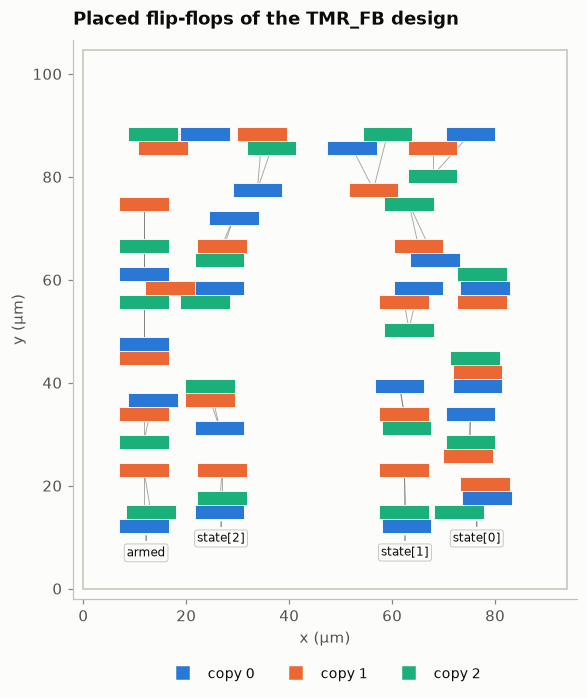

In [44]:
import itertools, random

FF_PLACEMENT_CACHE = {
    "cell": "sky130_fd_sc_hd__dfrtp_2",
    "die": [0.0, 0.0, 93.89, 104.61],
    "core": [5.52, 10.88, 88.32, 92.48],
    # register, copy, bit, x, y (lower-left corner, µm)
    "rows": [
        ("armed", 0, 0, 6.9, 10.88),
        ("armed", 1, 0, 6.9, 21.76),
        ("armed", 2, 0, 8.28, 13.6),
        ("state", 0, 0, 73.6, 16.32),
        ("state", 0, 1, 57.96, 10.88),
        ("state", 0, 2, 21.62, 13.6),
        ("state", 1, 0, 73.14, 19.04),
        ("state", 1, 1, 57.5, 21.76),
        ("state", 1, 2, 22.08, 21.76),
        ("state", 2, 0, 68.08, 13.6),
        ("state", 2, 1, 57.5, 13.6),
        ("state", 2, 2, 22.08, 16.32),
        ("timer", 0, 0, 28.98, 76.16),
        ("timer", 0, 1, 18.86, 87.04),
        ("timer", 0, 2, 6.9, 59.84),
        ("timer", 0, 3, 70.38, 87.04),
        ("timer", 0, 4, 24.38, 70.72),
        ("timer", 0, 5, 63.48, 62.56),
        ("timer", 0, 6, 47.38, 84.32),
        ("timer", 0, 7, 73.14, 57.12),
        ("timer", 0, 8, 6.9, 46.24),
        ("timer", 0, 9, 21.62, 29.92),
        ("timer", 0, 10, 56.58, 38.08),
        ("timer", 0, 11, 60.26, 57.12),
        ("timer", 0, 12, 21.62, 57.12),
        ("timer", 0, 13, 71.76, 38.08),
        ("timer", 0, 14, 8.74, 35.36),
        ("timer", 0, 15, 70.38, 32.64),
        ("timer", 1, 0, 29.9, 87.04),
        ("timer", 1, 1, 10.58, 84.32),
        ("timer", 1, 2, 6.9, 73.44),
        ("timer", 1, 3, 63.02, 84.32),
        ("timer", 1, 4, 22.08, 65.28),
        ("timer", 1, 5, 60.26, 65.28),
        ("timer", 1, 6, 51.52, 76.16),
        ("timer", 1, 7, 72.68, 54.4),
        ("timer", 1, 8, 6.9, 43.52),
        ("timer", 1, 9, 19.78, 35.36),
        ("timer", 1, 10, 57.5, 32.64),
        ("timer", 1, 11, 57.5, 54.4),
        ("timer", 1, 12, 11.96, 57.12),
        ("timer", 1, 13, 71.76, 40.8),
        ("timer", 1, 14, 6.9, 32.64),
        ("timer", 1, 15, 69.92, 24.48),
        ("timer", 2, 0, 31.74, 84.32),
        ("timer", 2, 1, 8.74, 87.04),
        ("timer", 2, 2, 6.9, 65.28),
        ("timer", 2, 3, 63.02, 78.88),
        ("timer", 2, 4, 21.62, 62.56),
        ("timer", 2, 5, 58.42, 73.44),
        ("timer", 2, 6, 54.28, 87.04),
        ("timer", 2, 7, 72.68, 59.84),
        ("timer", 2, 8, 6.9, 54.4),
        ("timer", 2, 9, 19.78, 38.08),
        ("timer", 2, 10, 57.96, 29.92),
        ("timer", 2, 11, 58.42, 48.96),
        ("timer", 2, 12, 18.86, 54.4),
        ("timer", 2, 13, 71.3, 43.52),
        ("timer", 2, 14, 6.9, 27.2),
        ("timer", 2, 15, 70.38, 27.2),
    ],
}

ROW_H = 2.72   # SKY130 HD row height (µm)


def read_ff_placement(def_path):
    """Placed flip-flops of every protected register, traced through the nets their Q pins drive."""
    txt = Path(def_path).read_text()
    units = int(re.search(r"UNITS DISTANCE MICRONS (\d+)", txt).group(1))
    comp = {n: (c, int(x) / units, int(y) / units) for n, c, x, y in re.findall(
        r"^\s*-\s+(\S+)\s+(\S+)\s+\+\s+(?:PLACED|FIXED)\s+\(\s*(-?\d+)\s+(-?\d+)\s*\)", txt, re.M)}
    nets = re.search(r"^NETS.*?^END NETS", txt, re.M | re.S).group(0)
    rows = []
    for m in re.finditer(r"^\s*-\s+(\S+)(.*?);", nets, re.M | re.S):
        name = re.match(r"u_fsm\.u_(\w+)\..*?\bg\.r(\d)\\\[(\d+)\\\]$", m.group(1))
        drv = re.search(r"\(\s*(\S+)\s+Q\s*\)", m.group(2))
        if name and drv:
            cell, x, y = comp[drv.group(1)]
            rows.append(dict(register=name.group(1), copy=int(name.group(2)), bit=int(name.group(3)),
                             cell=cell, x=x, y=y))
    die = [int(v) / units for v in
           re.search(r"DIEAREA\s*\(\s*(\d+)\s+(\d+)\s*\)\s*\(\s*(\d+)\s+(\d+)", txt).groups()]
    return pd.DataFrame(rows), die


def cell_width(cell, default=9.66):
    """Cell width from its liberty area; every SKY130 HD cell is one row tall."""
    if not TT_LIB:
        return default
    global _LIB_TEXT
    if "_LIB_TEXT" not in globals():
        _LIB_TEXT = Path(TT_LIB).read_text()
    m = re.search(r'cell\s*\(\s*"?%s"?\s*\)\s*\{.*?area\s*:\s*([\d.]+)' % re.escape(cell), _LIB_TEXT, re.S)
    return float(m.group(1)) / ROW_H if m else default


def_candidates = [Path("pnr/runs/tmr_fb_T20/final/def/top_tmr_fb.def"), Path("top_tmr_fb.def"),
                  *sorted(Path("pnr/runs").glob("tmr_fb_T20*/final/def/*.def"))]
def_path = next((p for p in def_candidates if p.is_file()), None)
if def_path:
    ff, die = read_ff_placement(def_path)
    source = f"layout file {def_path}"
else:
    ff = pd.DataFrame(FF_PLACEMENT_CACHE["rows"], columns=["register", "copy", "bit", "x", "y"])
    ff["cell"] = FF_PLACEMENT_CACHE["cell"]
    die = FF_PLACEMENT_CACHE["die"]
    source = "embedded placement from a local run"
widths = {c: cell_width(c) for c in ff.cell.unique()}
ff["cx"] = ff.x + ff.cell.map(widths) / 2
ff["cy"] = ff.y + ROW_H / 2
print(f"{len(ff)} flip-flops from the {source}; cell {', '.join(widths)} is {list(widths.values())[0]:.2f} µm wide")


def closest_pairs(df):
    """For each logical bit, the distance between its two closest copies."""
    out = []
    for _, g in df.groupby(["register", "bit"]):
        pts = list(zip(g.cx, g.cy))
        out.append(min(math.dist(a, b) for a, b in itertools.combinations(pts, 2)))
    return np.array(sorted(out))


SEP_MIN = 10.0   # µm: a region constraint leaves a gap, so copies in different regions are at least a cell apart


def reassign(df, sites, rng, separated=False):
    """Hypothetical re-use of the same flip-flop sites.
    random:    copies assigned to sites at random (placement that ignores the replicas)
    separated: copy 0, 1, 2 confined to the left, middle and right third of the sites, no two copies of a
               bit closer than SEP_MIN (what a region constraint with a gap between regions would give)"""
    for _ in range(1000):
        d = df.copy()
        if separated:
            by_x = sorted(sites)
            n = len(by_x) // 3
            for c in range(3):
                band = by_x[c * n:(c + 1) * n] if c < 2 else by_x[2 * n:]
                band = band[:]; rng.shuffle(band)
                idx = d.index[d["copy"] == c]
                d.loc[idx, ["cx", "cy"]] = np.array(band[:len(idx)])
            if closest_pairs(d).min() >= SEP_MIN:
                return d
        else:
            s = sites[:]; rng.shuffle(s)
            d[["cx", "cy"]] = np.array(s)
            return d
    raise RuntimeError("no separated assignment found")


SITES = list(zip(ff.cx, ff.cy))
PLACEMENTS = {"as placed": "As placed by LibreLane", "random": "Copies on random sites",
              "separated": "One copy per region of the core"}
PL_STYLE = {"as placed": dict(color=MODE_COLOR["tmr_fb"], ls="-", marker="D"),
            "random": dict(color=MUTED, ls="--", marker="o"),
            "separated": dict(color="#4a3aa7", ls=":", marker="s")}
rng = random.Random(SEED)
variants = {"as placed": [ff],
            "random": [reassign(ff, SITES, rng) for _ in range(200)],
            "separated": [reassign(ff, SITES, rng, separated=True) for _ in range(200)]}
cp = {k: np.concatenate([closest_pairs(v) for v in vs]) for k, vs in variants.items()}

nn_sibling = 0
for i, r in ff.iterrows():
    d = np.hypot(ff.cx - r.cx, ff.cy - r.cy); d[i] = np.inf
    j = int(np.argmin(d))
    nn_sibling += (ff.loc[j, "register"], ff.loc[j, "bit"]) == (r.register, r.bit)

n_bits = len(cp["as placed"])
spacing = pd.DataFrame({
    "Closest pair, median (µm)": {PLACEMENTS[k]: np.median(v) for k, v in cp.items()},
    "Closest pair, largest (µm)": {PLACEMENTS[k]: v.max() for k, v in cp.items()},
    "Bits with copies in adjacent rows": {PLACEMENTS[k]: (v <= ROW_H * 1.05).mean() for k, v in cp.items()},
})
table(spacing, caption=f"Distance between the two closest copies of each of the {n_bits} triplicated bits",
      fmt={"Closest pair, median (µm)": "{:.1f}", "Closest pair, largest (µm)": "{:.1f}",
           "Bits with copies in adjacent rows": "{:.0%}"})
print(f"{nn_sibling} of {len(ff)} flip-flops have a copy of their own bit as their nearest flip-flop.")

# ---- layout map
COPY_COLOR = ["#2a78d6", "#eb6834", "#1baf7a"]
fig, ax = plt.subplots(figsize=(6.4, 6.6))
ax.add_patch(plt.Rectangle((die[0], die[1]), die[2] - die[0], die[3] - die[1], fill=False, ec=AXIS, lw=1))
for _, g in ff.groupby(["register", "bit"]):
    pts = g.sort_values("copy")[["cx", "cy"]].values
    for a, b in itertools.combinations(pts, 2):
        ax.plot([a[0], b[0]], [a[1], b[1]], color=INK2, lw=0.6, alpha=0.5, zorder=1)
for c in range(3):
    s = ff[ff["copy"] == c]
    for _, r in s.iterrows():
        ax.add_patch(plt.Rectangle((r.x, r.y), widths[r.cell], ROW_H, color=COPY_COLOR[c], ec=SURFACE,
                                   lw=0.6, zorder=2))
    ax.plot([], [], "s", color=COPY_COLOR[c], ms=8, label=f"copy {c}")
for (reg, bit), g in ff.groupby(["register", "bit"]):
    if reg != "timer":   # label the state and armed bits; the rest are timer bits
        ax.annotate(f"{reg}[{bit}]" if reg == "state" else reg, (g.cx.mean(), g.cy.min() - ROW_H / 2),
                    xytext=(0, -9), textcoords="offset points", ha="center", va="top", fontsize=8, color=INK,
                    zorder=5, bbox=dict(boxstyle="round,pad=0.2", fc=SURFACE, ec=AXIS, lw=0.6, alpha=0.95),
                    arrowprops=dict(arrowstyle="-", color=INK2, lw=0.6))
ax.set_xlim(die[0] - 2, die[2] + 2); ax.set_ylim(die[1] - 2, die[3] + 2)
ax.set_aspect("equal"); ax.grid(False)
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=9)
ax.set_title("Placed flip-flops of the TMR_FB design")
save(fig, "replica_placement"); plt.show()

*Figure 6. Placed flip-flops of the TMR_FB design, coloured by copy. Grey lines join the three copies of each bit;
labelled groups are `state` and `armed`, the rest are `timer` bits.*

The placer stacks the copies of each bit on top of each other. It minimises wire length, and the three copies of a bit
share the same input and feed the same voter, so it pulls them together. That is the right choice for timing and the
wrong one for radiation tolerance.

To translate geometry into mission outcomes, the fault campaign is rerun with a spatial strike model. Each strike
lands on a randomly chosen flip-flop and upsets every flip-flop whose centre lies within a radius *r* of it, all in
the same cycle. The radius stands in for the charge-sharing range of a real particle strike, which depends on the
particle, its angle and the process, so results are shown across a range of radii rather than for one assumed value.
The same strikes are applied to the real placement and to the two hypothetical assignments of the same flip-flop
sites: copies on random sites, and one copy per region of the core with a gap between regions.

Spatial campaign: 21 conditions x 2,000 flights in 181 s


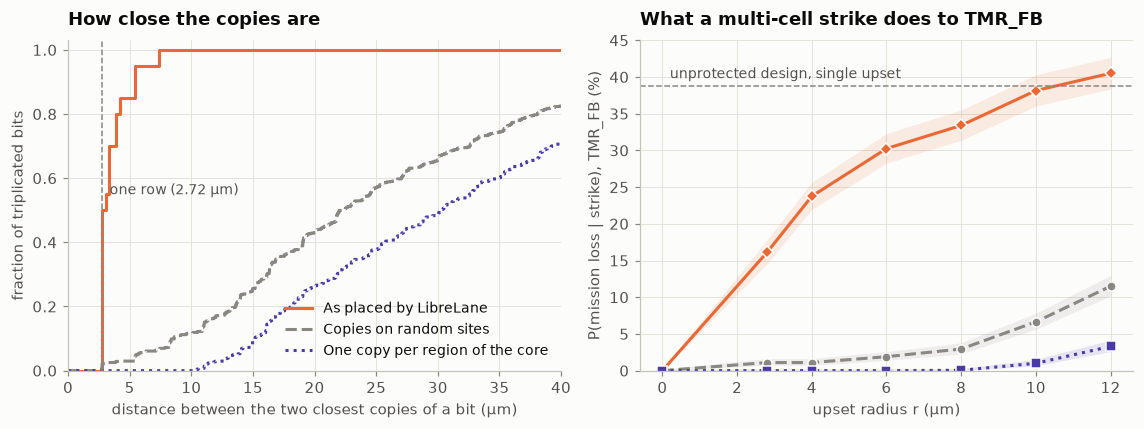

,0 µm,2.8 µm,4 µm,6 µm,8 µm,10 µm,12 µm
As placed by LibreLane,0.0%,16.1%,23.8%,30.2%,33.4%,38.1%,40.5%
Copies on random sites,0.0%,1.1%,1.1%,1.9%,2.9%,6.7%,11.5%
One copy per region of the core,0.0%,0.0%,0.0%,0.0%,0.1%,1.0%,3.3%


In [45]:
sys.path.insert(0, os.getcwd())
import fault_campaign as fc

MBU_TRIALS = 2000
MBU_RADII = [0, 2.8, 4, 6, 8, 10, 12]     # µm; 2.8 reaches the row above and below

sim_fb = fc.build("tmr_fb", Path("build"), [Path("prot_reg.v"), Path("recovery_fsm.v"), Path("tb_campaign.v")])
nb_fb, segs_fb = fc.probe(sim_fb)
seg = {name: (off, w) for name, off, w, _ in segs_fb}
assert nb_fb == len(ff), "layout and simulation storage maps disagree"
flat = lambda r: seg[r.register][0] + int(r.copy) * seg[r.register][1] + int(r.bit)

prng = random.Random(SEED + 3)
profiles = fc.make_profiles(prng, MBU_TRIALS)
draws = [(prng.randint(fc.RST_CYC, p[4] - 1), prng.random()) for p in profiles]
mbu_rows = []
t0 = time.time()
for key, vs in variants.items():
    vs = vs[:5]                                   # each flight uses one of up to 5 assignments
    pts = [(v[["cx", "cy"]].to_numpy(), np.array([flat(r) for r in v.itertuples()])) for v in vs]
    for rad in MBU_RADII:
        sched = []
        for i, (p, (cyc, u)) in enumerate(zip(profiles, draws)):
            xy, idx = pts[i % len(pts)]
            hit = xy[min(int(u * len(xy)), len(xy) - 1)]
            near = idx[np.hypot(*(xy - hit).T) <= rad + 1e-9]
            sched.append((p, [(cyc, int(b)) for b in near]))
        mbu_res = fc.simulate(sim_fb, sched, Path("build"), "mbu")
        oc = [fc.classify(r, p) for (p, _), r in zip(sched, mbu_res)]
        loss = sum(o.startswith("LOSS") for o in oc)
        p_, lo, hi = fc.wilson(loss, MBU_TRIALS)
        mbu_rows.append(dict(placement=key, radius=rad, p_loss=p_, lo=lo, hi=hi,
                             upsets=np.mean([len(f) for _, f in sched])))
mbu = pd.DataFrame(mbu_rows)
print(f"Spatial campaign: {len(mbu)} conditions x {MBU_TRIALS:,} flights in {time.time() - t0:.0f} s")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 4.0))
for key, v in cp.items():
    xs = np.sort(v)
    a1.step(np.r_[0, xs, 40], np.r_[0, np.arange(1, len(xs) + 1) / len(xs), 1], where="post",
            color=PL_STYLE[key]["color"], ls=PL_STYLE[key]["ls"], label=PLACEMENTS[key])
a1.axvline(ROW_H, color=MUTED, lw=1, ls="--")
a1.text(ROW_H, 0.55, "  one row (2.72 µm)", color=INK2, fontsize=9)
a1.set_xlim(0, 40); a1.set_ylim(0, 1.03)
a1.set_xlabel("distance between the two closest copies of a bit (µm)")
a1.set_ylabel("fraction of triplicated bits")
a1.set_title("How close the copies are")
a1.legend(loc="lower right", fontsize=9)

for key in PLACEMENTS:
    d = mbu[mbu.placement == key]
    a2.plot(d.radius, d.p_loss * 100, color=PL_STYLE[key]["color"], ls=PL_STYLE[key]["ls"],
            marker=PL_STYLE[key]["marker"], markersize=6, markeredgecolor=SURFACE, label=PLACEMENTS[key])
    a2.fill_between(d.radius, d.lo * 100, d.hi * 100, color=PL_STYLE[key]["color"], alpha=0.12, lw=0)
none_loss = rel.loc["none", "p_loss"] * 100
a2.axhline(none_loss, color=MUTED, lw=1, ls="--")
a2.text(0.2, none_loss + 1, "unprotected design, single upset", color=INK2, fontsize=9)
a2.set_xlabel("upset radius r (µm)"); a2.set_ylabel("P(mission loss | strike), TMR_FB (%)")
a2.set_ylim(0, max(45, none_loss + 6))
a2.set_title("What a multi-cell strike does to TMR_FB")
fig.tight_layout()
save(fig, "multi_bit_upsets"); plt.show()

mt = mbu.pivot(index="placement", columns="radius", values="p_loss").loc[list(PLACEMENTS)]
mt.index = [PLACEMENTS[k] for k in mt.index]
mt.columns = [f"{c:g} µm" for c in mt.columns]
table(mt, fmt="{:.1%}", caption=f"P(mission loss) for TMR_FB under a strike of radius r, {MBU_TRIALS:,} flights each")

*Figure 7. Left: distribution of the distance between the two closest copies of each triplicated bit. Right:
probability of mission loss for TMR_FB when a strike upsets every flip-flop within radius r, for the real placement and
two hypothetical assignments of the same sites. Shaded bands are 95% confidence intervals.*

In [46]:
def mbu_at(placement, radius):
    return mbu[(mbu.placement == placement) & (mbu.radius == radius)].iloc[0]


def zero_loss_radius(placement):
    """Largest radius such that no flight was lost at that radius or any smaller one."""
    best = None
    for _, r in mbu[mbu.placement == placement].sort_values("radius").iterrows():
        if r.p_loss > 0:
            break
        best = r.radius
    return best


a28, r28, s28 = (mbu_at(k, 2.8) for k in ("as placed", "random", "separated"))
mbu_safe = zero_loss_radius("separated")
text = (f"With a radius of zero (a single-bit upset) no placement loses a flight, as in section 10.1. As soon as a "
        f"strike can reach the row above or below (r = 2.8 µm), TMR_FB as placed loses {a28.p_loss:.1%} of flights, "
        f"{a28.p_loss / rel.loc['none', 'p_loss']:.0%} of the unprotected design's single-upset loss rate. The same "
        f"strike loses {r28.p_loss:.1%} with the copies on random sites and {s28.p_loss:.1%} with one copy per region.")
if mbu_safe:
    text += (f" With one copy per region, no flight was lost at any radius up to {mbu_safe:g} µm, "
             f"{mbu_safe / ROW_H:.1f} row heights in every direction.")
text += " The protection is lost to placement rather than to the logic, so it can be recovered without changing the RTL."
display(Markdown(text))

With a radius of zero (a single-bit upset) no placement loses a flight, as in section 10.1. As soon as a strike can reach the row above or below (r = 2.8 µm), TMR_FB as placed loses 16.1% of flights, 41% of the unprotected design's single-upset loss rate. The same strike loses 1.1% with the copies on random sites and 0.0% with one copy per region. With one copy per region, no flight was lost at any radius up to 6 µm, 2.2 row heights in every direction. The protection is lost to placement rather than to the logic, so it can be recovered without changing the RTL.

## 11. A bug found by the campaign

The first campaign run of DMR recorded one loss in 3,000 single upsets, which a detect-only scheme should not allow.
The trace showed an upset flipping `state` copy 0 from `BOOST` (001) to `DROGUE` (011) during powered flight. DMR's
output follows copy 0 and the pyro outputs are combinational, so for one clock, before the mismatch moved the
controller to `SAFE`, `drogue_fire` was high under thrust.

The fix is a rule that applies to every detect-only scheme: gate the outputs on the copies agreeing. In
`recovery_fsm` this is the `GATE_PYRO` parameter, which blocks the pyro outputs in fail-silent mode in the same cycle a
mismatch appears. The ungated version is kept in the campaign as `dmr_ungated` for comparison.

In [47]:
cmp_ = rel.loc[["dmr_ungated", "dmr"]]
mcd = mc[mc["mode"].isin(["dmr", "dmr_ungated"])].pivot(index="upsets_per_bit", columns="mode", values="p_loss")
lam = mcd.index.max()
bug = pd.DataFrame({
    "Single-upset losses": [f"{round(r.p_loss * r.trials)} of {int(r.trials):,}" for _, r in cmp_.iterrows()],
    "95% CI": [f"{r.p_loss_ci_lo:.3%} – {r.p_loss_ci_hi:.3%}" for _, r in cmp_.iterrows()],
    f"P(loss) at λ = {lam:g}": [mcd.loc[lam, m] for m in cmp_.index],
}, index=["DMR, ungated outputs", "DMR, gated outputs"])
table(bug, caption="Effect of gating the pyro outputs on the copies agreeing",
      fmt={f"P(loss) at λ = {lam:g}": "{:.1%}"})

,Single-upset losses,95% CI,P(loss) at λ = 0.3
"DMR, ungated outputs","1 of 3,000",0.006% – 0.189%,1.2%
"DMR, gated outputs","0 of 3,000",0.000% – 0.128%,0.5%


One clock of exposure is invisible to a functional test and to the hand-written scenarios of section 5. It only
appears when thousands of upsets land at random times, which is the main argument for running a fault campaign on any
hardened design rather than trusting the hardening by construction.

## 12. The cost–reliability trade-off

Each mode is placed at its logic-area cost from LibreLane against its loss probability under accelerated upsets from
the campaign. A mode is Pareto-optimal if no other mode is both cheaper and more reliable. The right-hand panel shows
availability: how often the primary controller completes the mission after one upset.

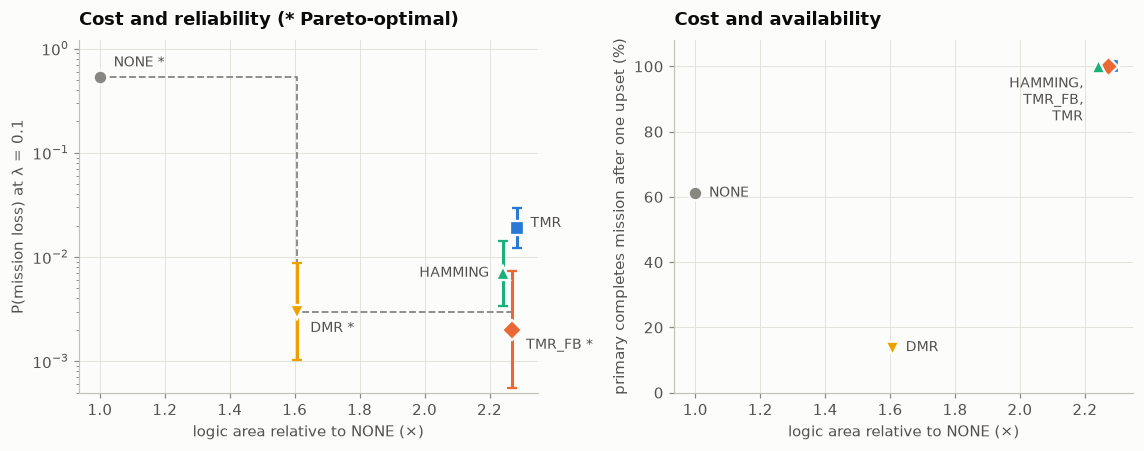

,Area vs NONE,P(loss) at λ = 0.1,Availability,Pareto-optimal
NONE,1.00×,53.8%,61%,yes
TMR,2.28×,1.9%,100%,
TMR_FB,2.27×,0.2%,100%,yes
HAMMING,2.24×,0.7%,100%,
DMR,1.61×,0.3%,14%,yes


In [48]:
PARETO_LAMBDA = 0.1
at = mc[mc.upsets_per_bit == PARETO_LAMBDA].set_index("mode")
pt = pd.DataFrame({
    "area_x": ref.logic_area_um2 / base.logic_area_um2,
    "p_loss": at.p_loss, "lo": at.p_loss_ci_lo, "hi": at.p_loss_ci_hi,
    "availability": rel.p_nominal,
}).loc[order]

frontier, best_p = [], float("inf")
for m, r in pt.sort_values(["area_x", "p_loss"]).iterrows():
    if r.p_loss < best_p:
        frontier.append(m); best_p = r.p_loss

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 4.2))
fx = pt.loc[frontier]
a1.step(fx.area_x, np.maximum(fx.p_loss, 1e-4), where="post", color=MUTED, lw=1.2, ls="--", zorder=1)
for m, r in pt.iterrows():
    p = max(r.p_loss, 1e-4)
    a1.errorbar(r.area_x, p, yerr=[[p - max(r.lo, 1e-4)], [r.hi - p]],
                fmt=MODE_MARKER[m], color=MODE_COLOR[m], ms=9, mec=SURFACE, mew=1.5, capsize=3, zorder=3)
    dx, dy, ha = {"hamming": (-9, 0, "right"), "tmr_fb": (9, -10, "left"), "dmr": (9, -11, "left"),
                  "none": (9, 9, "left")}.get(m, (9, 3, "left"))
    a1.annotate(MODE_LABEL[m] + (" *" if m in frontier else ""), (r.area_x, p),
                xytext=(dx, dy), textcoords="offset points", color=INK2, fontsize=9, ha=ha, va="center")
a1.set_yscale("log"); a1.set_ylim(5e-4, 1.2)
a1.set_xlabel("logic area relative to NONE (×)")
a1.set_ylabel(f"P(mission loss) at λ = {PARETO_LAMBDA}")
a1.set_title("Cost and reliability (* Pareto-optimal)")

for m, r in pt.iterrows():
    a2.scatter(r.area_x, r.availability * 100, marker=MODE_MARKER[m], color=MODE_COLOR[m], s=80,
               edgecolor=SURFACE, linewidth=1.5, zorder=3)
clusters = []       # modes that sit on top of each other share one label
for m, r in pt.sort_values("area_x").iterrows():
    for c in clusters:
        if abs(c["x"] - r.area_x) < 0.12 and abs(c["y"] - r.availability) < 0.02:
            c["names"].append(MODE_LABEL[m]); break
    else:
        clusters.append(dict(x=r.area_x, y=r.availability, names=[MODE_LABEL[m]]))
for c in clusters:
    many = len(c["names"]) > 1
    a2.annotate(",\n".join(c["names"]), (c["x"], c["y"] * 100), xytext=(-10, -6) if many else (9, 0),
                textcoords="offset points", color=INK2, fontsize=9,
                ha="right" if many else "left", va="top" if many else "center")
a2.set_ylim(0, 108); a2.set_xlabel("logic area relative to NONE (×)")
a2.set_ylabel("primary completes mission after one upset (%)")
a2.set_title("Cost and availability")
fig.tight_layout()
save(fig, "pareto"); plt.show()

po = pd.DataFrame({
    "Area vs NONE": pt.area_x,
    f"P(loss) at λ = {PARETO_LAMBDA:g}": pt.p_loss,
    "Availability": pt.availability,
    "Pareto-optimal": ["yes" if m in frontier else "" for m in pt.index],
})
table(labelled(po), caption="Trade-off summary",
      fmt={"Area vs NONE": "{:.2f}×", f"P(loss) at λ = {PARETO_LAMBDA:g}": "{:.1%}", "Availability": "{:.0%}"})

*Figure 8. Left: logic-area cost against probability of mission loss at λ = 0.1, with 95% confidence intervals; the
dashed line is the Pareto frontier. Right: logic-area cost against availability of the primary controller.*

Read together, the two panels give a clear ranking. NONE is the cheapest and fails most often. DMR is the cheapest
protection and loses almost nothing, but only by handing most upset flights to the backup altimeter, which makes it the
right choice only when a backup exists and availability does not matter. TMR_FB dominates plain TMR, with essentially
the same area, fewer losses under accumulation and a higher clock frequency, so there is no reason to build plain TMR.
HAMMING costs as much area as TMR_FB at this design's register widths and runs at half the speed. The accelerated
losses of TMR_FB and HAMMING are upper bounds, as noted in section 10.3.

## 13. Scaling with register width

The controller's registers are 1, 3 and 16 bits wide. To obtain a rule that holds beyond this one design, each mode is
synthesised as a bare register at widths from 1 to 64 bits and mapped to SKY130 HD cells at the typical corner with
Yosys and ABC.

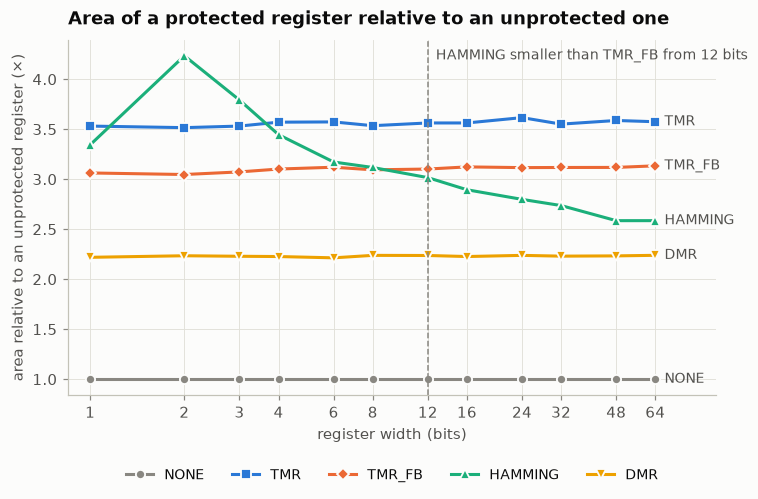

,TMR,TMR_FB,HAMMING,DMR,HAMMING ÷ TMR_FB
1 bit,3.53,3.06,3.34,2.22,1.09
2 bits,3.52,3.05,4.23,2.23,1.39
3 bits,3.53,3.07,3.79,2.23,1.23
4 bits,3.57,3.10,3.45,2.23,1.11
6 bits,3.57,3.12,3.17,2.21,1.02
8 bits,3.54,3.09,3.12,2.24,1.01
12 bits,3.56,3.10,3.02,2.24,0.97
16 bits,3.56,3.12,2.89,2.23,0.93
24 bits,3.62,3.12,2.80,2.24,0.90
32 bits,3.55,3.12,2.74,2.23,0.88


In [49]:
Path("wrap.v").write_text("""module wrap #(parameter integer W = 8, parameter MODE = "NONE") (
    input clk, rst, en, input [W-1:0] d, output [W-1:0] q, output err);
    prot_reg #(.W(W), .MODE(MODE)) u (.clk(clk), .rst(rst), .en(en), .d(d), .q(q), .err(err));
endmodule
""")
WIDTHS = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64]


def reg_area(job):
    mode, W = job
    stat = f"build/area_{mode}_{W}.txt"
    run([YOSYS, "-q", "-p",
         f'read_verilog prot_reg.v wrap.v; chparam -set W {W} -set MODE "{mode}" wrap; '
         f"synth -flatten -top wrap; dfflibmap -liberty {TT_LIB} -dont_use *lpflow*; "
         f"abc -liberty {TT_LIB} -dont_use *lpflow*; opt_clean; tee -o {stat} stat -liberty {TT_LIB}"])
    area = float(re.search(r"Chip area for module.*?:\s*([\d.]+)", Path(stat).read_text()).group(1))
    return dict(mode=mode, width=W, area_um2=area)


cross = None
if HAVE["Yosys"] and HAVE["SKY130 library"]:
    jobs = [(MODE_PARAM[m], W) for m in MODES for W in WIDTHS]
    with ThreadPoolExecutor(4) as ex:
        ws = pd.DataFrame(list(ex.map(reg_area, jobs)))
    ws["mode"] = ws["mode"].map({v: k for k, v in MODE_PARAM.items()})
    wsp = ws.pivot(index="width", columns="mode", values="area_um2")[order]
    per_bit = wsp.div(wsp["none"], axis=0)
    ratio = wsp["hamming"] / wsp["tmr_fb"]
    cross = next((W for W in WIDTHS if (ratio.loc[[w for w in WIDTHS if w >= W]] < 1).all()), None)

    fig, ax = plt.subplots(figsize=(7.6, 4.2))
    for m in order:
        ax.plot(per_bit.index, per_bit[m], color=MODE_COLOR[m], marker=MODE_MARKER[m], markersize=6,
                markeredgecolor=SURFACE, markeredgewidth=1.2, label=MODE_LABEL[m])
        ax.annotate(MODE_LABEL[m], (per_bit.index[-1], per_bit[m].iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", va="center", color=INK2, fontsize=9)
    if cross:
        ax.axvline(cross, color=MUTED, lw=1, ls="--")
        ax.text(cross, ax.get_ylim()[1] * 0.98, f"  HAMMING smaller than TMR_FB from {cross} bits", va="top",
                color=INK2, fontsize=9)
    ax.set_xscale("log", base=2); ax.set_xticks(WIDTHS, [str(w) for w in WIDTHS])
    ax.set_xlim(0.85, 100)
    ax.set_xlabel("register width (bits)"); ax.set_ylabel("area relative to an unprotected register (×)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), fontsize=9, ncol=5)
    ax.set_title("Area of a protected register relative to an unprotected one")
    save(fig, "width_sweep"); plt.show()

    wt = per_bit.drop(columns="none").rename(columns=MODE_LABEL)
    wt["HAMMING ÷ TMR_FB"] = ratio
    wt.index = [f"{w} bit{'s' if w > 1 else ''}" for w in wt.index]
    table(wt, fmt="{:.2f}",
          caption="Area relative to an unprotected register of the same width (SKY130 HD, typical corner)")
else:
    print("Yosys or the SKY130 library not available: skipped.")

*Figure 9. Area of a protected register relative to an unprotected register of the same width, SKY130 HD.*

Three results generalise beyond this design. TMR_FB is smaller than plain TMR at every width. Plain TMR holds each
copy's own value when not written, which needs an enable multiplexer per copy because SKY130 has no flip-flop with both
an enable and an asynchronous reset; TMR_FB loads all three copies with the same value (`en ? d : voted`), so the
copies share a single multiplexer and the repair saves area rather than costing it. HAMMING becomes smaller than TMR_FB
at about 8 bits and keeps improving with width, since its parity grows only as log₂ W, but at 2 to 3 bits it is the
most expensive option, and at 1 bit it degenerates into a repetition code with the same cost as TMR_FB. DMR costs a
constant of about 2.2×, the floor for any scheme that keeps two copies.

## 14. Power

LibreLane reports power from OpenSTA without simulation activity: it assumes default toggle rates and propagates them
through the logic. The estimate is shown below for completeness but is not used in any ranking.

In [50]:
pw = pd.DataFrame({
    "Internal (µW)": ref.power_internal_uW,
    "Switching (µW)": ref.power_switching_uW,
    "Leakage (nW)": ref.power_leakage_uW * 1e3,
    "Total (µW)": ref.power_total_uW,
    "Total vs NONE": ref.power_total_uW / ref.loc["none", "power_total_uW"],
})
table(labelled(pw), caption="Vectorless power estimate at a 20 ns clock (OpenSTA)",
      fmt={"Internal (µW)": "{:,.0f}", "Switching (µW)": "{:,.0f}", "Leakage (nW)": "{:.1f}",
           "Total (µW)": "{:,.0f}", "Total vs NONE": "{:.1f}×"})

,Internal (µW),Switching (µW),Leakage (nW),Total (µW),Total vs NONE
NONE,98,23,2.8,122,1.0×
TMR,266,77,6.7,342,2.8×
TMR_FB,245,60,6.8,305,2.5×
HAMMING,898,930,7.2,"1,828",15.0×
DMR,249,99,4.7,348,2.9×


Vectorless propagation is least reliable through deep XOR trees, which is exactly what the Hamming decoder consists of.
During development, two functionally identical Hamming implementations (loop-based RTL and XOR-wiring RTL) produced
vectorless totals more than ten times apart. A trustworthy comparison needs switching activity from simulated flights
annotated into the power analysis, which is left as future work rather than reported as a result.

## 15. Design rules

The rules below are generated from the results of this notebook.

In [51]:
rules = []
p0 = rel.loc["none"]
rules.append(f"Protect the state. One upset loses an unprotected flight {p0.p_loss:.0%} of the time "
             f"(95% CI {p0.p_loss_ci_lo:.0%} to {p0.p_loss_ci_hi:.0%}), and every protected mode recorded zero "
             f"single-upset losses in {int(p0.trials):,} flights.")
if "trap" in globals():
    rules.append("Verify redundancy on the netlist, not the RTL. Textbook TMR synthesised to "
                 f"{int(trap.loc['TMR_NOKEEP', 'Flip-flops after synthesis'])} flip-flops instead of 60.")
hi = mc.upsets_per_bit.max()
pm = mc[mc.upsets_per_bit == hi].set_index("mode").p_loss
rules.append(f"Use feedback TMR rather than plain TMR. At λ = {hi:g} plain TMR lost {pm['tmr']:.1%} of flights "
             f"against {pm['tmr_fb']:.1%} for TMR_FB, at no extra area.")
if cross:
    rules.append(f"Choose Hamming only for wide registers. Below {cross} bits TMR_FB is smaller; from {cross} bits "
                 f"Hamming wins, by {1 - ratio.loc[64]:.0%} at 64 bits.")
if best is not None:
    rules.append(f"Keep Hamming out of fast feedback loops. In this controller it cut the sign-off frequency from "
                 f"{best.loc['none', 'fmax_MHz']:.0f} MHz to {best.loc['hamming', 'fmax_MHz']:.0f} MHz, against "
                 f"{best.loc['tmr_fb', 'fmax_MHz']:.0f} MHz for TMR_FB.")
ug, g = rel.loc["dmr_ungated"], rel.loc["dmr"]
rules.append(f"Gate the outputs of any detect-only scheme. Ungated DMR fired a parachute during boost; gating "
             f"reduced single-upset losses from {round(ug.p_loss * ug.trials)} to {round(g.p_loss * g.trials)}.")
rules.append(f"Treat DMR as safe but not available. It handed {g.p_safe:.0%} of single-upset flights to the backup "
             "altimeter.")
if "mbu" in globals():
    rules.append(f"Separate the copies physically. As placed by LibreLane, a strike reaching one row above or "
                 f"below lost {a28.p_loss:.0%} of TMR_FB flights; with one copy per region of the core, "
                 f"{s28.p_loss:.1%}.")
display(Markdown("\n".join(f"{i}. {r}" for i, r in enumerate(rules, 1))))

1. Protect the state. One upset loses an unprotected flight 39% of the time (95% CI 37% to 41%), and every protected mode recorded zero single-upset losses in 3,000 flights.
2. Verify redundancy on the netlist, not the RTL. Textbook TMR synthesised to 20 flip-flops instead of 60.
3. Use feedback TMR rather than plain TMR. At λ = 0.3 plain TMR lost 12.2% of flights against 1.3% for TMR_FB, at no extra area.
4. Choose Hamming only for wide registers. Below 12 bits TMR_FB is smaller; from 12 bits Hamming wins, by 17% at 64 bits.
5. Keep Hamming out of fast feedback loops. In this controller it cut the sign-off frequency from 193 MHz to 97 MHz, against 171 MHz for TMR_FB.
6. Gate the outputs of any detect-only scheme. Ungated DMR fired a parachute during boost; gating reduced single-upset losses from 1 to 0.
7. Treat DMR as safe but not available. It handed 86% of single-upset flights to the backup altimeter.
8. Separate the copies physically. As placed by LibreLane, a strike reaching one row above or below lost 16% of TMR_FB flights; with one copy per region of the core, 0.0%.

## 16. Limitations and future work

The study has six main limitations.

- Upsets are injected into flip-flops only. Voters, decoders and next-state logic are never struck, so single-event
  transients are not modelled and the voters themselves remain single points of failure.
- Faults are injected at register-transfer level. This is valid because section 6 and the LibreLane runs confirm that
  every storage bit survives synthesis; `TMR_NOKEEP` shows what happens when it does not.
- Simulated flights are compressed to about 250 cycles, so coincident-upset failures of TMR_FB and HAMMING are
  overestimated (section 10.3).
- Multiple-bit upsets are modelled geometrically (section 10.4): a strike upsets every flip-flop whose centre lies
  within a chosen radius. The radius at which neighbouring SKY130 cells actually share charge would need beam
  testing or device-level simulation, and only the TMR_FB layout at a 20 ns clock was analysed.
- Power is vectorless (section 14).
- There is one demonstrator design. The width sweep generalises the area results, but the reliability results depend
  on this controller's structure.

Several extensions follow directly. The direct follow-up to section 10.4 is to constrain
placement so that each copy occupies its own region of the core, re-run the flow, and measure the area and timing
cost of the protection it recovers. The library already allows a different `MODE` for each register instance, so selective hardening
(heavy protection for `state` and `armed`, cheaper protection for the timer, as section 10.2 suggests) is a small step.
Other natural next steps are activity-annotated power from simulated flights, gate-level and single-event-transient
injection on the final netlist, and cell-level hardening such as DICE flip-flops characterised in SPICE and compared on
the same axes.

## 17. Reproducing this notebook

On Colab, run all cells. The install cells take about ten minutes and the fault campaign about two; place-and-route
uses the embedded results unless `RUN_PNR` is set to `True`. To run locally, start Jupyter inside LibreLane's
`nix-shell` with Icarus Verilog installed. To regenerate the place-and-route results, set `RUN_PNR = True`, run all
cells, call `print_cache()`, and paste its output over `PNR_CACHE` in section 8. Set `LIBRELANE_VERSION` in section 1
to the release used for the embedded results; LibreLane's `pdk_hashes.yaml` then pins the PDK version. The fault
campaign is fully determined by `SEED`.

In [52]:
print(f"{'LibreLane':<16}{LIBRELANE_VERSION_FOUND}")
for name, tool in (("Icarus Verilog", "iverilog"), ("Yosys", YOSYS)):
    try:
        v = subprocess.run([tool, "-V"], capture_output=True, text=True).stdout.splitlines()
        print(f"{name:<16}{v[0] if v else '?'}")
    except Exception as e:
        print(f"{name:<16}{e}")
print(f"{'Python':<16}{sys.version.split()[0]}")

LibreLane       3.0.14
Icarus Verilog  Icarus Verilog version 13.0 (devel) ()
Yosys           Yosys 0.62 (git sha1 7326bb7d6641500ecb285c291a54a662cb1e76cf, clang++ 21.1.2 -fPIC -O3)
Python          3.13.9


## 18. References

1. M. Young, *An Automated Triple Modular Redundancy EDA Flow for Yosys*, BCompSc (Honours) thesis, The University of
   Queensland, 2024. https://mlyoung.cool/publications/An_Automated_TMR_Flow_for_Yosys.pdf
2. TMRX: Triple Modular Redundancy Expansion for Yosys. https://github.com/Xelef2000/TMRX
3. M. Shalan and T. Edwards, "Building OpenLANE: A 130nm OpenROAD-based tapeout-proven flow," in *Proc. ICCAD*, 2020.
   LibreLane: https://github.com/librelane/librelane
4. SkyWater SKY130 open-source PDK. https://github.com/google/skywater-pdk
5. R. W. Hamming, "Error detecting and error correcting codes," *Bell System Technical Journal*, vol. 29, no. 2, 1950.
6. R. E. Lyons and W. Vanderkulk, "The use of triple-modular redundancy to improve computer reliability," *IBM Journal
   of Research and Development*, vol. 6, no. 2, 1962.
7. S. S. Mukherjee et al., "A systematic methodology to compute the architectural vulnerability factors for a
   high-performance microprocessor," in *Proc. MICRO-36*, 2003.
8. E. B. Wilson, "Probable inference, the law of succession, and statistical inference," *Journal of the American
   Statistical Association*, vol. 22, no. 158, 1927.
9. C. Wolf, Yosys Open Synthesis Suite, https://github.com/YosysHQ/yosys; S. Williams, Icarus Verilog,
   https://github.com/steveicarus/iverilog

Licensed under the Apache License 2.0.